# California SEN: county-scale 2D versus 3D validation

The statewide 2D graph uses OSM footprints selected from the union of the Interface, Intermix, and Influence Zone classes plus a three-mile buffer, whereas the county 3D graph uses LARIAC footprints. Raw node IDs therefore cannot be joined. This validation extracts the statewide buildings inside the transformed 3D county envelope, constructs a conservative one-to-one crosswalk from mutual-nearest footprint centroids within 5 m, and compares $F_{ij}=\max(F_{i\to j},F_{j\to i})$ only for building pairs present in both graphs. Cluster membership is not computed in this first validation step.

In [1]:
import os
import sys
from pathlib import Path

import duckdb
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from shapely.geometry import box

cwd = Path.cwd().resolve()
PACKAGE_ROOT = next(
    path for path in [cwd, *cwd.parents]
    if (path / 'data').exists() and (path / 'src').exists()
    and (path / 'notebooks').exists()
)
sys.path.insert(0, str(PACKAGE_ROOT))

from src.analysis.carsen import (
    build_county_extent_crosswalk,
    build_shared_pair_comparison, build_statewide_components,
    build_statewide_ranked_incidence, fit_2d_fragility,
    logistic_5pl, pair_comparison_summary,
)
from src.viz.style import apply_style
from src.viz.carsen import (
    build_component_spatial_summary, load_california_context,
    plot_statewide_panel,
)

apply_style()
STATE_2D_RUN = Path(os.environ.get(
    'OPENVIEW_CA_2D_BVF_DIR',
    '/Users/adamswietek/Documents/PostDoc/openview/results/'
    'california_wui_all_3mi_osm_2d/full_california',
))
COUNTY_3D_RUN = Path(os.environ.get(
    'OPENVIEW_3D_BVF_DIR',
    '/Users/adamswietek/Documents/PostDoc/openview/results/'
    'lariac6_wui_all_2mi_bvf_3d_nf_cone85_nosolar',
))
COUNTY_BUILDINGS = (
    PACKAGE_ROOT / 'data' / 'derived' / 'openview3d_lariac6_2mi'
    / 'county_buildings.parquet'
)
STATE_RUN_TAG = 'california_wui_all_3mi_osm_2d'
DERIVED = (
    PACKAGE_ROOT / 'data' / 'derived' / 'carsen_2d_vs_3d' / STATE_RUN_TAG
)
RESULTS = PACKAGE_ROOT / 'results' / 'carsen_2d_vs_3d' / STATE_RUN_TAG
FIGURES = PACKAGE_ROOT / 'figures' / 's2s_nc' /'main'/ STATE_RUN_TAG
for directory in (DERIVED, RESULTS, FIGURES):
    directory.mkdir(parents=True, exist_ok=True)

required_state_outputs = [
    STATE_2D_RUN / name for name in (
        'manifest.json', 'building_ids.parquet', 'building_edges.parquet'
    )
]
missing_state_outputs = [path for path in required_state_outputs if not path.exists()]
empty_state_outputs = [
    path for path in required_state_outputs if path.exists() and path.stat().st_size == 0
]
if missing_state_outputs or empty_state_outputs:
    raise RuntimeError(
        'The three-mile California OpenView run is not finalized. '
        f'Missing: {missing_state_outputs}; empty: {empty_state_outputs}'
    )

EXTENT_BUILDINGS = DERIVED / 'state_2d_buildings_in_county_3d_extent.parquet'
CROSSWALK = DERIVED / 'county_3d_to_state_2d_building_crosswalk.parquet'
PAIR_COMPARISON = DERIVED / 'county_matched_pair_F_2d_vs_3d.parquet'
CALIBRATION_DERIVED = (
    PACKAGE_ROOT / 'data' / 'derived' / 'carsen_2d_vs_3d'
)
FIRE_DOSE = CALIBRATION_DERIVED / 'fire_building_dose_2d.parquet'
FRAGILITY_TABLE = RESULTS / 'fragility_parameters_2d.csv'
STATE_COMPONENTS = DERIVED / 'statewide_components'
RANKED_INCIDENCE = STATE_COMPONENTS / 'california_top2_ranked_incidence.parquet'
SOURCE_PROJECT = PACKAGE_ROOT.parent
STATE_CENTROIDS = DERIVED / 'california_building_centroids_2d.parquet'
CA_BOUNDARY = SOURCE_PROJECT / 'data' / 'reference' / 'cb_2025_us_state_500k.zip'
CA_WUI_CLASSES = (
    SOURCE_PROJECT / 'data' / 'reference'
    / 'california_interface_intermix_influence_75m.parquet'
)
TOP2_EDGE_FLOOR_ALPHA = 0.75
STATE_COMPONENTS_CTOP2_ALPHA075 = (
    STATE_COMPONENTS / 'absolute_p50_ctop2_alpha075'
)
SPATIAL_DIR = STATE_COMPONENTS_CTOP2_ALPHA075 / 'spatial'


In [2]:
extent_path, crosswalk_path, extent_summary = build_county_extent_crosswalk(
    COUNTY_BUILDINGS, STATE_2D_RUN, EXTENT_BUILDINGS, CROSSWALK,
    maximum_centroid_distance_m=5.0,
)
extent_summary.to_csv(RESULTS / 'county_extent_crosswalk_summary.csv', index=False)
display(extent_summary.T.rename(columns={0: 'value'}))
print('2D county-extent extraction:', extent_path)
print('LARIAC–OSM crosswalk:', crosswalk_path)


,value
county_3d_buildings,1628455
state_2d_buildings_in_3d_extent,2121457
mutual_matches_within_distance,1402402
maximum_centroid_distance_m,5.0
share_of_3d_buildings_matched,0.861186
share_of_extent_2d_buildings_matched,0.661056
median_centroid_distance_m,1.248088
p95_centroid_distance_m,1.924441
county_extent_crs,EPSG:3310
county_extent_xmin,94292.811703


2D county-extent extraction: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/carsen_2d_vs_3d/california_wui_all_3mi_osm_2d/state_2d_buildings_in_county_3d_extent.parquet
LARIAC–OSM crosswalk: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/carsen_2d_vs_3d/california_wui_all_3mi_osm_2d/county_3d_to_state_2d_building_crosswalk.parquet


In [3]:
comparison_path = build_shared_pair_comparison(
    STATE_2D_RUN, COUNTY_3D_RUN, CROSSWALK, PAIR_COMPARISON,
)
correlation = pair_comparison_summary(comparison_path)
correlation.to_csv(RESULTS / 'county_matched_pair_F_correlation.csv', index=False)
display(correlation.T.rename(columns={0: 'value'}))
print('matched pair comparison:', comparison_path)


,value
shared_positive_pairs,1.233004e+07
pearson_r_raw,7.988868e-01
pearson_r_log10,8.648080e-01
log10_slope,1.337424e+00
log10_intercept,-5.810230e-01
median_F_2d,2.490542e-02
median_F_3d,1.433506e-03


matched pair comparison: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/carsen_2d_vs_3d/california_wui_all_3mi_osm_2d/county_matched_pair_F_2d_vs_3d.parquet


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/s2s_nc/main/california_wui_all_3mi_osm_2d/carsen_county_matched_F_2d_vs_3d.png


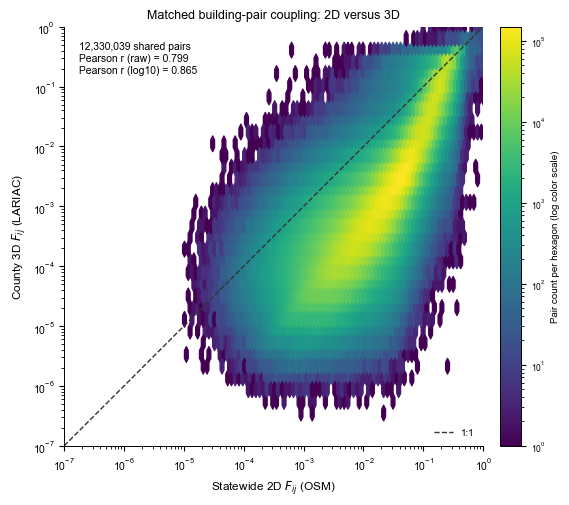

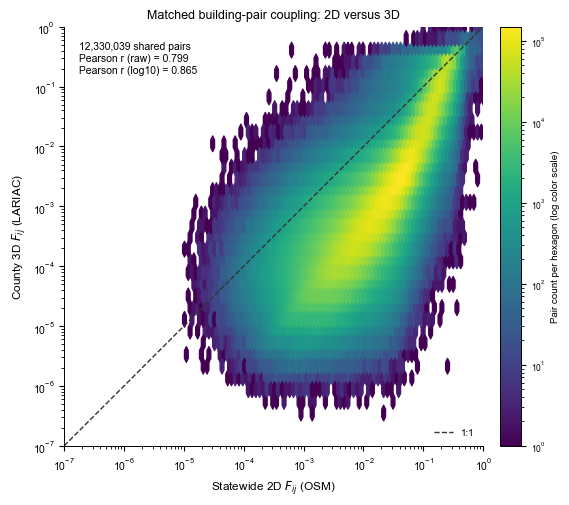

In [4]:
pairs = pd.read_parquet(PAIR_COMPARISON, columns=['F_2d', 'F_3d'])
positive = pairs.F_2d.gt(0) & pairs.F_3d.gt(0)
pairs = pairs.loc[positive]
stats = correlation.iloc[0]
limits = (1e-7, 1.0)
fig, ax = plt.subplots(figsize=(5.8, 5.1))
hexbin = ax.hexbin(
    pairs.F_2d, pairs.F_3d, xscale='log', yscale='log',
    gridsize=80, mincnt=1, bins='log', cmap='viridis',
)
ax.plot(limits, limits, color='.2', lw=1, ls='--', label='1:1')
ax.set(
    xlim=limits, ylim=limits, aspect='equal',
    xlabel=r'Statewide 2D $F_{ij}$ (OSM)',
    ylabel=r'County 3D $F_{ij}$ (LARIAC)',
    title='Matched building-pair coupling: 2D versus 3D',
)
ax.text(
    .035, .965,
    f"{int(stats.shared_positive_pairs):,} shared pairs\n"
    f"Pearson r (raw) = {stats.pearson_r_raw:.3f}\n"
    f"Pearson r (log10) = {stats.pearson_r_log10:.3f}",
    transform=ax.transAxes, ha='left', va='top', fontsize=7.5,
    bbox=dict(facecolor='white', edgecolor='none', alpha=.85),
)
ax.legend(frameon=False, loc='lower right', fontsize=7)
cbar = fig.colorbar(hexbin, ax=ax, fraction=.046, pad=.035)
cbar.set_label('Pair count per hexagon (log color scale)', fontsize=7)
cbar.ax.tick_params(labelsize=6)
fig.tight_layout()
stem = FIGURES / 'carsen_county_matched_F_2d_vs_3d'
fig.savefig(stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white')
fig.savefig(stem.with_suffix('.png'), dpi=600, bbox_inches='tight', facecolor='white')
print('saved', stem.with_suffix('.png'))
fig


## Statewide clustering threshold from 2D fire fragility

Following `notebooks/06_2d_perimeter_fragility_network.ipynb`, realized exposure was reconstructed on the LARIAC 2D graph as the cumulative incoming `vf` from destroyed neighbors. That fire-dose calibration sample is fixed and is reused here because changing the statewide OSM selection buffer does not alter Eaton–Palisades dose reconstruction. Separate Eaton and Palisades curves and a pooled five-parameter logistic curve are fitted. For the statewide maps, the threshold is the dose at an absolute fitted $P(\mathrm{destroyed})=0.50$, matching the threshold convention used in `05_regional_sen_extent.ipynb`.

,metric,model,fire,n,p_min,p_max,k,hill,asymmetry,asymptotic_f50,absolute_p50,brier,log_loss,parameter_at_bound
0,dose_sum,5PL,EATON,14200,0.024716,0.966586,0.299870,2.646366,0.799934,0.265610,0.267615,0.118840,0.383913,False
1,dose_sum,5PL,PALISADES,10103,0.034246,0.983808,0.534867,4.206323,0.205438,0.241817,0.236327,0.133007,0.418450,False
2,dose_sum,5PL,POOLED,24303,0.029943,0.972098,0.413133,3.152647,0.405902,0.256096,0.255567,0.125705,0.402286,False


Pooled 5PL absolute P=.50 dose: 0.255566729


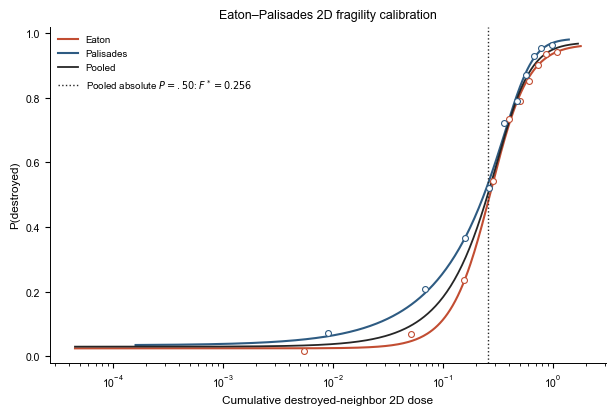

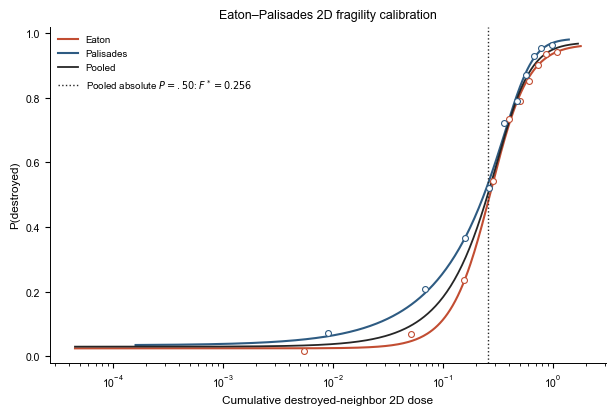

In [5]:
# Resolve independently so a stale kernel cannot retain the former run-specific path.
FIRE_DOSE = (
    PACKAGE_ROOT / 'data' / 'derived' / 'carsen_2d_vs_3d'
    / 'fire_building_dose_2d.parquet'
)
if not FIRE_DOSE.exists():
    raise FileNotFoundError(
        'The fixed Eaton–Palisades 2D fire-dose cache is missing: '
        f'{FIRE_DOSE}'
    )
dose_path = FIRE_DOSE
fragility_table, fragility_fits = fit_2d_fragility(dose_path)
fragility_table.to_csv(FRAGILITY_TABLE, index=False)
pooled_fit = fragility_fits['POOLED']
F_2D_ABSOLUTE_P50 = float(pooled_fit['absolute_p50'])
if not np.isfinite(F_2D_ABSOLUTE_P50):
    raise RuntimeError('Pooled 2D fit does not cross absolute P=.50')
if pooled_fit['parameter_at_bound']:
    raise RuntimeError('Pooled 2D fragility fit reached a parameter bound')
display(fragility_table.round(6))
print(f'Pooled 5PL absolute P=.50 dose: {F_2D_ABSOLUTE_P50:.9f}')

dose = pd.read_parquet(dose_path)
colors = {'EATON': '#C24D32', 'PALISADES': '#2E5B82'}
fig, ax = plt.subplots(figsize=(6.2, 4.2))
for fire in ('EATON', 'PALISADES'):
    sample = dose[dose.fire.eq(fire) & dose.dose_sum.gt(0)].copy()
    sample['bin'] = pd.qcut(sample.dose_sum, 10, duplicates='drop')
    binned = sample.groupby('bin', observed=True).agg(
        dose=('dose_sum', lambda values: np.exp(np.log(values).mean())),
        probability=('is_destroyed', 'mean'),
    )
    fit = fragility_fits[fire]
    grid = np.geomspace(sample.dose_sum.min(), sample.dose_sum.quantile(.999), 400)
    ax.plot(grid, fit['fn'](grid, *fit['parameters']), color=colors[fire],
            label=fire.title())
    ax.scatter(binned.dose, binned.probability, s=18, facecolor='white',
               edgecolor=colors[fire], linewidth=.8, zorder=3)
pooled_positive = dose.loc[dose.dose_sum.gt(0), 'dose_sum']
pooled_grid = np.geomspace(
    pooled_positive.min(), pooled_positive.quantile(.999), 400,
)
ax.plot(pooled_grid, pooled_fit['fn'](pooled_grid, *pooled_fit['parameters']),
        color='.15', lw=1.3, label='Pooled')
ax.axvline(F_2D_ABSOLUTE_P50, color='.15', lw=1, ls=':',
           label=fr'Pooled absolute $P=.50$: $F^*={F_2D_ABSOLUTE_P50:.3f}$')
ax.set(xscale='log', ylim=(-.02, 1.02), xlabel='Cumulative destroyed-neighbor 2D dose',
       ylabel='P(destroyed)', title='Eaton–Palisades 2D fragility calibration')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, fontsize=7)
fig.tight_layout()
fragility_stem = FIGURES / 'carsen_2d_fragility_absolute_p50'
fig.savefig(fragility_stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white')
fig.savefig(fragility_stem.with_suffix('.png'), dpi=600, bbox_inches='tight', facecolor='white')
fig


## California cumulative Top-2 network

The statewide network uses the pooled cumulative-dose threshold associated with absolute fitted $P(\mathrm{destroyed})=0.50$ and the completed three-mile combined-WUI graph. **Cumulative Top-2** requires two ranked incident neighbors whose scores sum to at least $F^*$. Following `05_rsen.ipynb`, retained links must connect two qualifying endpoints and each individual coupling must reach $\alpha F^*$, with $\alpha=0.75$. Components are labeled over every statewide graph node, so buildings outside the qualifying network remain explicit singletons.

In [6]:
ranked_path = build_statewide_ranked_incidence(
    STATE_2D_RUN, RANKED_INCIDENCE, maximum_rank=2,
)
top2_paths = build_statewide_components(
    STATE_2D_RUN, STATE_COMPONENTS_CTOP2_ALPHA075,
    F_2D_ABSOLUTE_P50, 'top2', ranked_path=ranked_path, n_neighbors=2,
    edge_floor_fraction=TOP2_EDGE_FLOOR_ALPHA,
)
statewide_summary = pd.read_csv(top2_paths['summary'])
statewide_summary.to_csv(
    RESULTS / 'california_ctop2_alpha075_cluster_summary_absolute_p50.csv',
    index=False,
)
display(statewide_summary)
print('Cumulative Top-2 alpha=.75 assignments:', top2_paths['assignments'])


,region,method,threshold,neighbors_summed,edge_floor_fraction,individual_edge_floor,nodes,candidate_pairs,qualifying_buildings,active_edges,all_node_components,connected_components,largest_component
0,California WUI sample,top2,0.255567,2,0.75,0.191675,7204007,81350243,5713922,2808855,4416161,1223216,164


Cumulative Top-2 alpha=.75 assignments: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/carsen_2d_vs_3d/california_wui_all_3mi_osm_2d/statewide_components/absolute_p50_ctop2_alpha075/california_top2_assignments.parquet


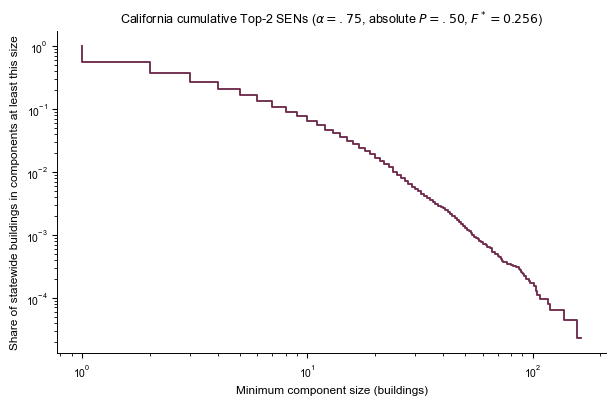

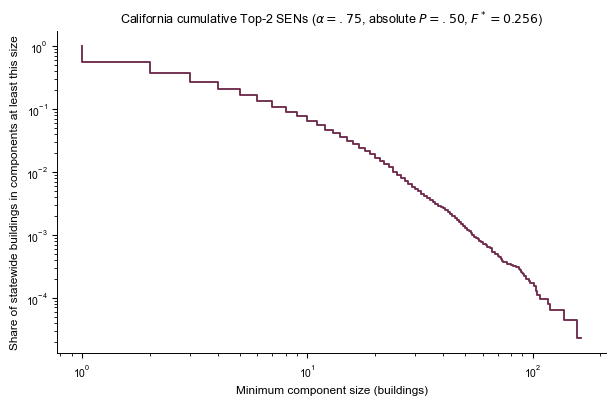

In [7]:
fig, ax = plt.subplots(figsize=(6.2, 4.1))
frequency = pd.read_csv(top2_paths['sizes']).sort_values(
    'component_size', ascending=False,
)
frequency['buildings_at_least'] = frequency.buildings.cumsum()
frequency['building_share'] = (
    frequency.buildings_at_least / frequency.buildings.sum()
)
ax.step(frequency.component_size, frequency.building_share, where='post',
        color='#702B4C', lw=1.35)
ax.set(xscale='log', yscale='log', xlabel='Minimum component size (buildings)',
       ylabel='Share of statewide buildings in components at least this size',
       title=fr'California cumulative Top-2 SENs ($\alpha=.75$, absolute $P=.50$, $F^*={F_2D_ABSOLUTE_P50:.3f}$)')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
size_stem = FIGURES / 'carsen_california_ctop2_alpha075_size_distribution_absolute_p50'
fig.savefig(size_stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white')
fig.savefig(size_stem.with_suffix('.png'), dpi=600, bbox_inches='tight', facecolor='white')
fig


## Statewide cumulative Top-2 map

The map uses the three-mile combined-WUI statewide graph and cumulative Top-2 clustering at the pooled absolute $P(\mathrm{destroyed})=0.50$ threshold with $\alpha=0.75$. Interface-connected component centroids are binned spatially; each occupied hexagon is colored by the largest component centered there on a logarithmic cubehelix scale. Influence, Intermix, and Interface boundaries remain visible as geographic context.


In [8]:
def build_state_centroids(run_dir, output_path):
    """Build a run-specific, length-weighted centroid cache for map joins."""
    if output_path.exists():
        return output_path
    patch_files = list((run_dir / 'patches').glob('*.parquet'))
    if not patch_files:
        raise FileNotFoundError(f"No patch parquet files under {run_dir / 'patches'}")
    partial = output_path.with_suffix(output_path.suffix + '.partial')
    partial.unlink(missing_ok=True)
    patch_glob = str(run_dir / 'patches' / '*.parquet').replace("'", "''")
    destination = str(partial).replace("'", "''")
    with duckdb.connect() as con:
        con.execute('SET threads=4')
        con.execute('SET preserve_insertion_order=false')
        con.execute(f"""
            COPY (
                SELECT building_id,
                       SUM(x_m * length_m) / SUM(length_m) AS x,
                       SUM(y_m * length_m) / SUM(length_m) AS y
                FROM read_parquet('{patch_glob}')
                GROUP BY building_id
            ) TO '{destination}' (FORMAT PARQUET, COMPRESSION ZSTD)
        """)
    partial.replace(output_path)
    return output_path

build_state_centroids(STATE_2D_RUN, STATE_CENTROIDS)
boundary, wui_classes = load_california_context(CA_BOUNDARY, CA_WUI_CLASSES)
assignment_paths = {'top2': top2_paths['assignments']}
component_summary_paths = {}
for method, assignment_path in assignment_paths.items():
    component_summary_paths[method] = build_component_spatial_summary(
        assignment_path, STATE_CENTROIDS, wui_classes,
        SPATIAL_DIR / f'california_{method}_component_spatial_summary.parquet',
    )
pd.DataFrame({'method': component_summary_paths.keys(), 'component_summary': component_summary_paths.values()})


,method,component_summary
0,top2,/Users/adamswietek/Documents/PostDoc/wildfire/...


In [9]:
boundary

,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
39,06,01779778,0400000US06,06,CA,California,00,403676564152,20288505023,"MULTIPOLYGON (((129777.289 -503034.64, 130301...."


In [10]:
wui_classes

{'Influence':              WUI_DESC                                              Shape
 24390  Influence Zone  POLYGON ((263128.875 -447899.489, 263158.875 -...
 24391  Influence Zone  POLYGON ((-44101.152 -375119.463, -44311.152 -...
 24392  Influence Zone  POLYGON ((-48601.152 -365969.462, -47971.152 -...
 24393  Influence Zone  POLYGON ((-49021.151 -356069.46, -48031.151 -3...
 24394  Influence Zone  POLYGON ((63718.856 -415169.474, 63778.856 -41...
 ...               ...                                                ...
 36152  Influence Zone  POLYGON ((65818.878 4230.569, 65848.878 4200.5...
 36153  Influence Zone  POLYGON ((65968.878 4500.569, 65998.878 4470.5...
 36154  Influence Zone  POLYGON ((74008.879 330.568, 75328.879 390.568...
 36155  Influence Zone  POLYGON ((67978.879 21750.571, 68728.879 21870...
 36156  Influence Zone  POLYGON ((68728.88 31410.572, 68698.88 31440.5...
 
 [11767 rows x 2 columns],
 'Intermix':        WUI_DESC                                          

,method,minimum_component_size,displayed_interface_connected_components,displayed_buildings,outside_mapped_wui_buildings,outside_mapped_wui_share,largest_displayed_component
0,top2,10,5754,79778,9134,0.114493,61


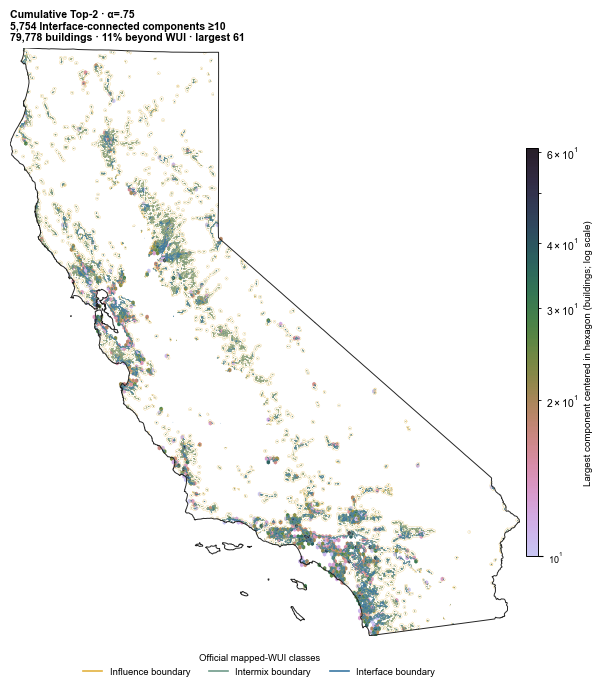

In [11]:
# California cumulative Top-2 clusters
# Reload so this cell always uses the saved statewide-plot API, even in a long-lived kernel.
import importlib
import src.viz.carsen as carsen_viz
importlib.reload(carsen_viz)

fig_a, summary_a = carsen_viz.plot_statewide_panel(
    boundary, wui_classes, component_summary_paths,
    FIGURES / 'carsen_california_ctop2_alpha075_absolute_p50',
    minimum_component_size=10,
    method_labels={'top2': 'Cumulative Top-2 · α=.75'},
)
summary_a.to_csv(
    RESULTS / 'carsen_california_ctop2_alpha075_statewide_summary_absolute_p50.csv',
    index=False,
)
display(summary_a)
# fig_a


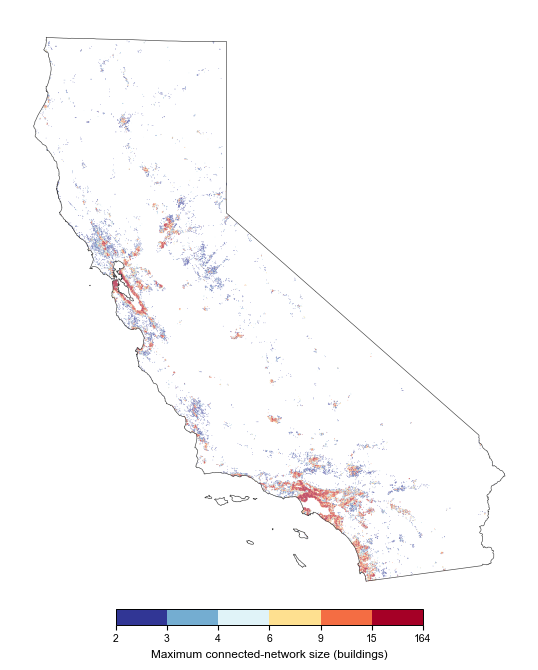

In [12]:
CMAP = 'RdYlBu_r'
clusters = pd.read_parquet(
    component_summary_paths['top2'],
    columns=['x', 'y', 'component_size'],
)
fig_max, ax_max = plt.subplots(figsize=(5.2, 6.5))
max_hex = ax_max.hexbin(
    clusters.x, clusters.y, C=clusters.component_size,
    reduce_C_function=np.max, gridsize=1_000, mincnt=1,
    cmap=CMAP, linewidths=0, rasterized=True
)
quantile_bounds = np.unique(np.rint(np.quantile(
    max_hex.get_array().compressed(), np.linspace(0, 1, 8),
)).astype(int))
max_hex.set_norm(mpl.colors.BoundaryNorm(
    quantile_bounds, plt.colormaps[CMAP].N, clip=True,
))
boundary.boundary.plot(ax=ax_max, color='#404040', linewidth=.45)
ax_max.set_aspect('equal')
ax_max.axis('off')
max_cbar = fig_max.colorbar(
    max_hex, ax=ax_max, orientation='horizontal',
    fraction=.025, pad=.0015, ticks=quantile_bounds,
)
max_cbar.set_ticklabels([f'{value:d}' for value in quantile_bounds])
max_cbar.set_label('Maximum connected-network size (buildings)')
fig_max.tight_layout(pad=0)
# max_cluster_stem = FIGURES / 'carsen_california_max_cluster_size_quantiles'
# fig_max.savefig(max_cluster_stem.with_suffix('.pdf'), bbox_inches='tight')
# fig_max.savefig(max_cluster_stem.with_suffix('.png'), dpi=600, bbox_inches='tight')
# fig_max


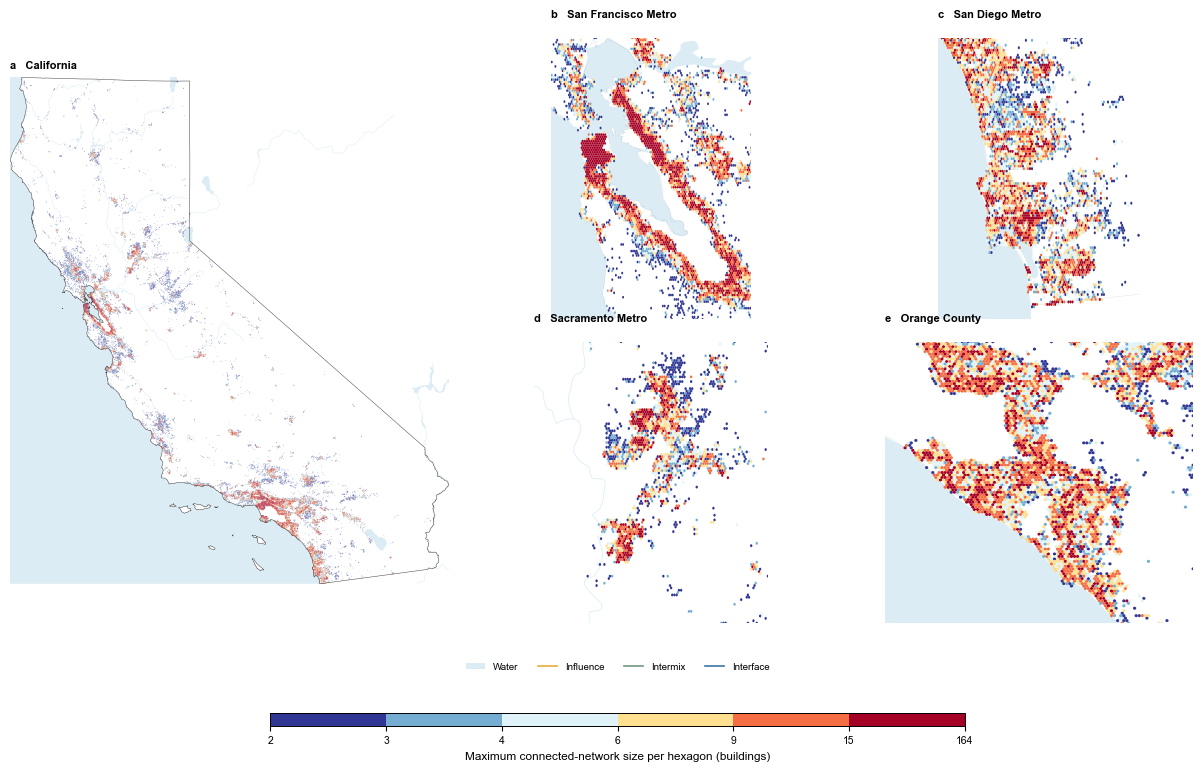

In [13]:
from matplotlib.patches import Patch
from pyproj import Transformer

METRO_BOUNDS = {
    'San Francisco Metro': (-122.65, 37.15, -121.75, 38.15),
    'San Diego Metro': (-117.40, 32.50, -116.80, 33.20),
    'Sacramento Metro': (-121.75, 38.20, -120.90, 39.00),
    'Orange County': (-118.15, 33.38, -117.40, 33.95),
}
METRO_WUI_COLORS = {
    'Influence': '#E5AE38',
    'Intermix': '#6F9880',
    'Interface': '#3B78A3',
}
metro_wui = {
    name: frame.to_crs(3857)
    for name, frame in wui_classes.items()
    if name in METRO_WUI_COLORS
}
metro_boundary = boundary.to_crs(3857)
to_web_mercator = Transformer.from_crs(
    boundary.crs, 3857, always_xy=True,
)
WATER_COLOR = '#DCECF4'
HYDRO_DIR = SOURCE_PROJECT / 'data' / 'reference' / 'natural_earth_hydro'
HYDRO_BBOX = (-125, 32, -113, 43)
metro_ocean = gpd.read_file(
    HYDRO_DIR / 'ne_10m_ocean.shp', bbox=HYDRO_BBOX,
).to_crs(3857)
metro_lakes = gpd.read_file(
    HYDRO_DIR / 'ne_10m_lakes.shp', bbox=HYDRO_BBOX,
).to_crs(3857)
metro_rivers = gpd.read_file(
    HYDRO_DIR / 'ne_10m_rivers_lake_centerlines.shp', bbox=HYDRO_BBOX,
).to_crs(3857)

fig_regions = plt.figure(figsize=(12.4, 7.6))
region_grid = fig_regions.add_gridspec(
    2, 3, width_ratios=(1.18, 1, 1), hspace=.08, wspace=.04,
)
state_ax = fig_regions.add_subplot(region_grid[:, 0])
metro_axes = np.array([
    [fig_regions.add_subplot(region_grid[0, 1]),
     fig_regions.add_subplot(region_grid[0, 2])],
    [fig_regions.add_subplot(region_grid[1, 1]),
     fig_regions.add_subplot(region_grid[1, 2])],
])

state_xmin, state_ymin, state_xmax, state_ymax = boundary.total_bounds
state_window = gpd.GeoSeries(
    [box(state_xmin, state_ymin, state_xmax, state_ymax)],
    crs=boundary.crs,
)
state_ocean = gpd.clip(metro_ocean.to_crs(boundary.crs), state_window)
state_lakes = gpd.clip(metro_lakes.to_crs(boundary.crs), state_window)
state_rivers = gpd.clip(metro_rivers.to_crs(boundary.crs), state_window)
state_ocean.plot(ax=state_ax, color=WATER_COLOR, linewidth=0, zorder=0)
state_lakes.plot(ax=state_ax, color=WATER_COLOR, linewidth=0, zorder=0)
state_rivers.plot(ax=state_ax, color=WATER_COLOR, linewidth=.35, zorder=1)
state_hex = state_ax.hexbin(
    clusters.x, clusters.y, C=clusters.component_size,
    reduce_C_function=np.max, gridsize=1_000, mincnt=1,
    cmap='RdYlBu_r', norm=max_hex.norm, linewidths=0,
    rasterized=True, zorder=2,
)
boundary.boundary.plot(
    ax=state_ax, color='#404040', linewidth=.35, zorder=6,
)
state_ax.set(
    xlim=(state_xmin, state_xmax), ylim=(state_ymin, state_ymax),
    aspect='equal',
)
state_ax.axis('off')
state_ax.set_title(
    'a   California', loc='left', fontsize=8, fontweight='bold',
)

for panel_label, ax, (name, lon_lat_bounds) in zip(
    'bcde', metro_axes.flat, METRO_BOUNDS.items(),
):
    state_window = gpd.GeoSeries(
        [box(*lon_lat_bounds)], crs='EPSG:4326',
    ).to_crs(boundary.crs)
    sxmin, symin, sxmax, symax = state_window.total_bounds
    metro_clusters = clusters.loc[
        clusters.x.between(sxmin, sxmax)
        & clusters.y.between(symin, symax)
    ]
    metro_x, metro_y = to_web_mercator.transform(
        metro_clusters.x.to_numpy(), metro_clusters.y.to_numpy(),
    )
    metro_window = gpd.GeoSeries(
        [box(*lon_lat_bounds)], crs='EPSG:4326',
    ).to_crs(3857)
    xmin, ymin, xmax, ymax = metro_window.total_bounds
    ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax))
    local_ocean = gpd.clip(metro_ocean, metro_window)
    local_lakes = gpd.clip(metro_lakes, metro_window)
    local_rivers = gpd.clip(metro_rivers, metro_window)
    if not local_ocean.empty:
        local_ocean.plot(ax=ax, color=WATER_COLOR, linewidth=0, zorder=0)
    if not local_lakes.empty:
        local_lakes.plot(ax=ax, color=WATER_COLOR, linewidth=0, zorder=0)
    if not local_rivers.empty:
        local_rivers.plot(ax=ax, color=WATER_COLOR, linewidth=.55, zorder=1)
    metro_hex = ax.hexbin(
        metro_x, metro_y,
        C=metro_clusters.component_size, reduce_C_function=np.max,
        gridsize=max(100, round((xmax - xmin) / 900)), mincnt=1,
        extent=(xmin, xmax, ymin, ymax), cmap='RdYlBu_r', norm=max_hex.norm,
        linewidths=0, rasterized=True,
    )
    # for wui_name, color in METRO_WUI_COLORS.items():
    #     local_wui = metro_wui[wui_name].cx[xmin:xmax, ymin:ymax]
    #     if not local_wui.empty:
    #         local_wui.boundary.plot(
    #             ax=ax, color='white', linewidth=1.15, zorder=4,
    #         )
    #         local_wui.boundary.plot(
    #             ax=ax, color=color, linewidth=.50, zorder=5,
    #         )
    metro_boundary.boundary.plot(ax=ax, color='#404040', linewidth=.045)
    ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
    ax.axis('off')
    ax.set_title(
        f'{panel_label}   {name}', loc='left',
        fontsize=8, fontweight='bold',
    )

fig_regions.subplots_adjust(
    left=.01, right=.99, top=.95, bottom=.18, hspace=.08, wspace=.04,
)
region_cbar_ax = fig_regions.add_axes([.22, .045, .56, .016])
region_cbar = fig_regions.colorbar(
    state_hex, cax=region_cbar_ax, orientation='horizontal',
    ticks=quantile_bounds,
)
region_cbar.set_ticklabels([f'{value:d}' for value in quantile_bounds])
region_cbar.set_label('Maximum connected-network size per hexagon (buildings)')
fig_regions.legend(
    handles=[
        Patch(facecolor=WATER_COLOR, edgecolor='none', label='Water'),
        *[Line2D([], [], color=color, linewidth=1.2, label=name)
          for name, color in METRO_WUI_COLORS.items()],
    ],
    loc='lower center', bbox_to_anchor=(.5, .105), ncol=4,
    frameon=False, fontsize=7,
)
# fig_regions


In [18]:
# ============================================================
# California connected-building networks and WUI classes
# Publication-ready regional figure
#
# Required existing objects:
#   boundary        California boundary GeoDataFrame
#   clusters        Table with x, y, and component_size
#   wui_classes     Dictionary of WUI GeoDataFrames
#   quantile_bounds Existing network-size class boundaries
#   SOURCE_PROJECT  pathlib.Path for the project
#
# Important:
#   - boundary geometry column: "geometry"
#   - WUI geometry column: "Shape"
# ============================================================

from pathlib import Path

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D
from pyproj import Transformer
from shapely.geometry import box


# ------------------------------------------------------------
# 1. Figure typography and export settings
# ------------------------------------------------------------

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": [
        "Arial",
        "Helvetica",
        "DejaVu Sans",
    ],
    "font.size": 6.5,
    "axes.titlesize": 7,
    "axes.labelsize": 6.5,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6.25,

    # Keep text editable in vector exports.
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",

    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})


# ------------------------------------------------------------
# 2. Geographic configuration
# ------------------------------------------------------------

METRO_BOUNDS = {
    "San Francisco Metro": (
        -122.65, 37.15,
        -121.75, 38.15,
    ),
    "San Diego Metro": (
        -117.40, 32.50,
        -116.80, 33.20,
    ),
    "Sacramento Metro": (
        -121.75, 38.20,
        -120.90, 39.00,
    ),
    "Orange County": (
        -118.15, 33.38,
        -117.40, 33.95,
    ),
}

WEB_MERCATOR = "EPSG:3857"

if boundary.crs is None:
    raise ValueError("boundary must have a defined CRS.")

required_cluster_columns = {
    "x",
    "y",
    "component_size",
}

missing_cluster_columns = (
    required_cluster_columns.difference(clusters.columns)
)

if missing_cluster_columns:
    raise ValueError(
        "clusters is missing required columns: "
        f"{sorted(missing_cluster_columns)}"
    )


# ------------------------------------------------------------
# 3. Visual hierarchy
# ------------------------------------------------------------

LAND_COLOR = "#FFFFFF"
WATER_COLOR = "#E6F1F6"
STATE_OUTLINE_COLOR = "#565656"

# Network-size bins from the existing analysis.
NETWORK_BOUNDS = np.asarray(
    quantile_bounds,
    dtype=float,
).copy()

# Make sure the final class includes the observed maximum.
observed_max = float(
    np.nanmax(clusters["component_size"])
)

NETWORK_BOUNDS[-1] = max(
    NETWORK_BOUNDS[-1],
    np.ceil(observed_max),
)

N_NETWORK_CLASSES = len(NETWORK_BOUNDS) - 1

if N_NETWORK_CLASSES < 2:
    raise ValueError(
        "quantile_bounds must define at least two intervals."
    )

# Sequential light-yellow to dark-red scale.
# Small networks remain contextual; large networks dominate.
base_network_cmap = mpl.colormaps["YlOrRd"]

NETWORK_COLORS = base_network_cmap(
    np.linspace(
        0.16,
        0.96,
        N_NETWORK_CLASSES,
    )
)

network_cmap = ListedColormap(
    NETWORK_COLORS,
    name="connected_network_size",
)

network_norm = BoundaryNorm(
    boundaries=NETWORK_BOUNDS,
    ncolors=network_cmap.N,
    clip=True,
)


# WUI colors avoid the yellow-orange-red network scale.
WUI_STYLES = {
    "Influence": {
        "color": "#252525",
        "linestyle": (0, (3.0, 1.5)),
        "label": "WUI influence",
    },
    "Intermix": {
        "color": "#0072B2",
        "linestyle": (0, (1.2, 1.2)),
        "label": "WUI intermix",
    },
    "Interface": {
        "color": "#6A3D9A",
        "linestyle": "solid",
        "label": "WUI interface",
    },
}

WUI_HALO_WIDTH = 1.15
WUI_LINE_WIDTH = 0.48

# Approximate display resolution of the hexagons.
DISPLAY_HEX_WIDTH_M = 900


# ------------------------------------------------------------
# 4. Prepare boundaries and WUI geometries
# ------------------------------------------------------------

# The California boundary shapefile uses "geometry".
state_boundary = (
    boundary[["geometry"]]
    .dissolve()
)

metro_boundary = (
    boundary[["geometry"]]
    .to_crs(WEB_MERCATOR)
    .dissolve()
)


# The WUI parquet files use "Shape", not "geometry".
metro_wui = {}

for name in WUI_STYLES:
    if name not in wui_classes:
        raise KeyError(
            f"wui_classes does not contain {name!r}. "
            f"Available classes: {list(wui_classes)}"
        )

    source_wui = wui_classes[name]

    if "Shape" not in source_wui.columns:
        raise KeyError(
            f"WUI class {name!r} does not contain a "
            "'Shape' column. "
            f"Available columns: {source_wui.columns.tolist()}"
        )

    projected = (
        source_wui
        .set_geometry("Shape")
        [["Shape"]]
        .rename_geometry("geometry")
        .to_crs(WEB_MERCATOR)
    )

    projected = projected.loc[
        projected.geometry.notna()
        & ~projected.geometry.is_empty
    ].copy()

    # Reprojection leaves a few self-intersecting rings (144 of the 16,884
    # Intermix polygons), and GEOS fails the dissolve on them with a side
    # location conflict, so they are repaired first.
    projected["geometry"] = projected.geometry.make_valid()
    projected = projected.loc[~projected.geometry.is_empty]

    # Dissolve adjacent polygons belonging to the same WUI class.
    # This eliminates unnecessary internal polygon boundaries.
    metro_wui[name] = (
        projected.dissolve()
        if not projected.empty
        else projected
    )


# Transformer for cluster coordinates.
to_web_mercator = Transformer.from_crs(
    boundary.crs,
    WEB_MERCATOR,
    always_xy=True,
)


# ------------------------------------------------------------
# 5. Load physical water layers
# ------------------------------------------------------------

HYDRO_DIR = (
    SOURCE_PROJECT
    / "data"
    / "reference"
    / "natural_earth_hydro"
)

HYDRO_BBOX = (
    -125,
    32,
    -113,
    43,
)

metro_ocean = gpd.read_file(
    HYDRO_DIR / "ne_10m_ocean.shp",
    bbox=HYDRO_BBOX,
).to_crs(WEB_MERCATOR)

metro_lakes = gpd.read_file(
    HYDRO_DIR / "ne_10m_lakes.shp",
    bbox=HYDRO_BBOX,
).to_crs(WEB_MERCATOR)


# ------------------------------------------------------------
# 6. Helper functions
# ------------------------------------------------------------

def add_panel_heading(ax, letter, title):
    """
    Add a bold 8-point panel letter and separate 7-point title.
    """

    ax.text(
        0.0,
        1.014,
        letter,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color="#111111",
        clip_on=False,
    )

    ax.annotate(
        title,
        xy=(0.0, 1.014),
        xycoords=ax.transAxes,
        xytext=(11, 0),
        textcoords="offset points",
        ha="left",
        va="bottom",
        fontsize=7,
        fontweight="normal",
        color="#111111",
        annotation_clip=False,
    )


def clean_map_axis(ax):
    """Remove map axes without changing the mapped extent."""

    ax.set_axis_off()
    ax.set_facecolor(LAND_COLOR)
    ax.margins(0)


def gridsize_from_extent(
    xmin,
    xmax,
    target_width_m=DISPLAY_HEX_WIDTH_M,
):
    """
    Calculate the horizontal hexbin gridsize required to produce
    approximately target_width_m-wide display cells.
    """

    return max(
        60,
        int(
            np.ceil(
                (xmax - xmin) / target_width_m
            )
        ),
    )


def plot_wui_boundaries(
    ax,
    xmin,
    ymin,
    xmax,
    ymax,
):
    """
    Plot each WUI class with a narrow colored line and white halo.
    """

    for name, style in WUI_STYLES.items():
        local_wui = metro_wui[name].cx[
            xmin:xmax,
            ymin:ymax,
        ]

        if local_wui.empty:
            continue

        local_boundary = local_wui.boundary

        # White separation halo.
        local_boundary.plot(
            ax=ax,
            color="white",
            linewidth=WUI_HALO_WIDTH,
            linestyle=style["linestyle"],
            alpha=0.96,
            zorder=5,
        )

        # Colored boundary.
        local_boundary.plot(
            ax=ax,
            color=style["color"],
            linewidth=WUI_LINE_WIDTH,
            linestyle=style["linestyle"],
            alpha=1.0,
            zorder=6,
        )


# ------------------------------------------------------------
# 7. Construct the figure
# ------------------------------------------------------------

# 7.20 inches is approximately 183 mm.
fig_regions = plt.figure(
    figsize=(7.20, 4.85),
    dpi=150,
)

region_grid = fig_regions.add_gridspec(
    nrows=2,
    ncols=3,
    width_ratios=(
        1.28,
        1.0,
        1.0,
    ),
    height_ratios=(
        1.0,
        1.0,
    ),
    left=0.018,
    right=0.994,
    top=0.963,
    bottom=0.190,
    wspace=0.055,
    hspace=0.075,
)

state_ax = fig_regions.add_subplot(
    region_grid[:, 0]
)

metro_axes = np.array([
    [
        fig_regions.add_subplot(region_grid[0, 1]),
        fig_regions.add_subplot(region_grid[0, 2]),
    ],
    [
        fig_regions.add_subplot(region_grid[1, 1]),
        fig_regions.add_subplot(region_grid[1, 2]),
    ],
])


# ------------------------------------------------------------
# 8. California panel
# ------------------------------------------------------------

(
    state_xmin,
    state_ymin,
    state_xmax,
    state_ymax,
) = state_boundary.total_bounds

state_window = gpd.GeoSeries(
    [
        box(
            state_xmin,
            state_ymin,
            state_xmax,
            state_ymax,
        )
    ],
    crs=boundary.crs,
)

state_ocean = gpd.clip(
    metro_ocean.to_crs(boundary.crs),
    state_window,
)

state_lakes = gpd.clip(
    metro_lakes.to_crs(boundary.crs),
    state_window,
)

if not state_ocean.empty:
    state_ocean.plot(
        ax=state_ax,
        color=WATER_COLOR,
        edgecolor="none",
        linewidth=0,
        zorder=0,
    )

if not state_lakes.empty:
    state_lakes.plot(
        ax=state_ax,
        color=WATER_COLOR,
        edgecolor="none",
        linewidth=0,
        zorder=0,
    )

state_gridsize = gridsize_from_extent(
    state_xmin,
    state_xmax,
)

state_hex = state_ax.hexbin(
    clusters["x"].to_numpy(),
    clusters["y"].to_numpy(),
    C=clusters["component_size"].to_numpy(),
    reduce_C_function=np.max,
    gridsize=state_gridsize,
    mincnt=1,
    extent=(
        state_xmin,
        state_xmax,
        state_ymin,
        state_ymax,
    ),
    cmap=network_cmap,
    norm=network_norm,
    linewidths=0,
    edgecolors="none",
    rasterized=True,
    zorder=2,
)

state_boundary.boundary.plot(
    ax=state_ax,
    color=STATE_OUTLINE_COLOR,
    linewidth=0.42,
    zorder=7,
)

state_ax.set(
    xlim=(state_xmin, state_xmax),
    ylim=(state_ymin, state_ymax),
    aspect="equal",
)

state_ax.set_anchor("C")

clean_map_axis(state_ax)
add_panel_heading(
    state_ax,
    "a",
    "California",
)


# ------------------------------------------------------------
# 9. Metro panels
# ------------------------------------------------------------

panel_letters = (
    "b",
    "c",
    "d",
    "e",
)

for panel_letter, ax, (
    name,
    lon_lat_bounds,
) in zip(
    panel_letters,
    metro_axes.flat,
    METRO_BOUNDS.items(),
):
    # Metro bounds in the coordinate system used by clusters.
    cluster_window = gpd.GeoSeries(
        [box(*lon_lat_bounds)],
        crs="EPSG:4326",
    ).to_crs(boundary.crs)

    (
        sxmin,
        symin,
        sxmax,
        symax,
    ) = cluster_window.total_bounds

    in_window = (
        clusters["x"].between(sxmin, sxmax)
        & clusters["y"].between(symin, symax)
    )

    metro_clusters = clusters.loc[
        in_window,
        [
            "x",
            "y",
            "component_size",
        ],
    ].copy()

    metro_x, metro_y = (
        to_web_mercator.transform(
            metro_clusters["x"].to_numpy(),
            metro_clusters["y"].to_numpy(),
        )
    )

    # Metro display bounds in Web Mercator.
    metro_window = gpd.GeoSeries(
        [box(*lon_lat_bounds)],
        crs="EPSG:4326",
    ).to_crs(WEB_MERCATOR)

    (
        xmin,
        ymin,
        xmax,
        ymax,
    ) = metro_window.total_bounds

    ax.set(
        xlim=(xmin, xmax),
        ylim=(ymin, ymax),
        aspect="equal",
    )

    # Water.
    local_ocean = gpd.clip(
        metro_ocean,
        metro_window,
    )

    local_lakes = gpd.clip(
        metro_lakes,
        metro_window,
    )

    if not local_ocean.empty:
        local_ocean.plot(
            ax=ax,
            color=WATER_COLOR,
            edgecolor="none",
            linewidth=0,
            zorder=0,
        )

    if not local_lakes.empty:
        local_lakes.plot(
            ax=ax,
            color=WATER_COLOR,
            edgecolor="none",
            linewidth=0,
            zorder=0,
        )

    # Connected-network hexagons.
    if not metro_clusters.empty:
        metro_gridsize = gridsize_from_extent(
            xmin,
            xmax,
        )

        ax.hexbin(
            metro_x,
            metro_y,
            C=metro_clusters[
                "component_size"
            ].to_numpy(),
            reduce_C_function=np.max,
            gridsize=metro_gridsize,
            mincnt=1,
            extent=(
                xmin,
                xmax,
                ymin,
                ymax,
            ),
            cmap=network_cmap,
            norm=network_norm,
            linewidths=0,
            edgecolors="none",
            rasterized=True,
            zorder=2,
        )

    # WUI class boundaries.
    plot_wui_boundaries(
        ax=ax,
        xmin=xmin,
        ymin=ymin,
        xmax=xmax,
        ymax=ymax,
    )

    # California/coast outline.
    local_boundary = metro_boundary.cx[
        xmin:xmax,
        ymin:ymax,
    ]

    if not local_boundary.empty:
        local_boundary.boundary.plot(
            ax=ax,
            color=STATE_OUTLINE_COLOR,
            linewidth=0.32,
            zorder=7,
        )

    # Reapply limits after GeoPandas plotting.
    ax.set(
        xlim=(xmin, xmax),
        ylim=(ymin, ymax),
        aspect="equal",
    )

    ax.set_anchor("C")

    clean_map_axis(ax)

    add_panel_heading(
        ax,
        panel_letter,
        name,
    )


# ------------------------------------------------------------
# 10. WUI legend
# ------------------------------------------------------------

wui_handles = [
    Line2D(
        [],
        [],
        color=style["color"],
        linewidth=1.35,
        linestyle=style["linestyle"],
        label=style["label"],
    )
    for style in WUI_STYLES.values()
]

fig_regions.legend(
    handles=wui_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.117),
    ncol=3,
    columnspacing=1.55,
    handlelength=2.6,
    handletextpad=0.55,
    borderaxespad=0,
    frameon=False,
    fontsize=6.25,
)


# ------------------------------------------------------------
# 11. Network-size colorbar
# ------------------------------------------------------------

region_cbar_ax = fig_regions.add_axes([
    0.245,  # left
    0.052,  # bottom
    0.560,  # width
    0.020,  # height
])

region_cbar = fig_regions.colorbar(
    state_hex,
    cax=region_cbar_ax,
    orientation="horizontal",
    boundaries=NETWORK_BOUNDS,
    ticks=NETWORK_BOUNDS,
    spacing="uniform",
    drawedges=False,
)

region_cbar.set_ticklabels([
    f"{int(value):,}"
    for value in NETWORK_BOUNDS
])

region_cbar.ax.tick_params(
    axis="x",
    which="both",
    direction="out",
    length=2.2,
    width=0.45,
    pad=1.5,
    labelsize=5.75,
    colors="#222222",
)

region_cbar.outline.set_edgecolor("#333333")
region_cbar.outline.set_linewidth(0.45)

region_cbar.set_label(
    "Maximum connected-network size within each hexagon (buildings)",
    fontsize=6.25,
    labelpad=2.5,
)


# ------------------------------------------------------------
# 12. Export SVG, PDF, and PNG
# ------------------------------------------------------------

OUTPUT_DIR = (
    SOURCE_PROJECT
    / "outputs"
    / "figures"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

svg_path = (
    OUTPUT_DIR
    / "connected_networks_california_metros.svg"
)

pdf_path = (
    OUTPUT_DIR
    / "connected_networks_california_metros.pdf"
)

png_path = (
    OUTPUT_DIR
    / "connected_networks_california_metros.png"
)

# SVG:
# - editable text
# - vector boundaries
# - embedded 600-dpi raster hexbin layers
fig_regions.savefig(
    svg_path,
    format="svg",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.025,
    facecolor="white",
)

# PDF:
# - editable TrueType text
# - vector boundaries
# - embedded 600-dpi raster hexbin layers
fig_regions.savefig(
    pdf_path,
    format="pdf",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.025,
    facecolor="white",
)

# PNG for review and manuscript drafting.
fig_regions.savefig(
    png_path,
    format="png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.025,
    facecolor="white",
)

plt.show()

print(f"Saved SVG: {svg_path}")
print(f"Saved PDF: {pdf_path}")
print(f"Saved PNG: {png_path}")

GEOSException: TopologyException: side location conflict at -13281375.647403765 4079183.8634813647. This can occur if the input geometry is invalid.

In [15]:
import shapely

TABLE_BIN_ORDER = [
    '1', '2–4', '5–9', '10–24', '25–99', '100–499', '500+',
]
TABLE_BIN_EDGES = [1, 2, 5, 10, 25, 100, 500, np.inf]
TABLE_ZONE_ORDER = [
    'Influence', 'Intermix', 'Interface',
    'Outside mapped WUI (≤2 mi)',
    'All structures in 2-mile sample',
]

table_assignments = pd.read_parquet(
    top2_paths['assignments'],
    columns=['building_id', 'component_size'],
)
table_centroids = pd.read_parquet(
    STATE_CENTROIDS, columns=['building_id', 'x', 'y'],
)
table_buildings = table_assignments.merge(
    table_centroids, on='building_id', validate='one_to_one',
)

table_wui_cache = DERIVED / 'california_building_wui_class.parquet'
if table_wui_cache.exists():
    table_wui = pd.read_parquet(table_wui_cache)
else:
    table_labels = np.full(
        len(table_buildings), 'Outside mapped WUI', dtype=object,
    )
    for wui_name in ('Influence', 'Intermix', 'Interface'):
        wui_geometry = wui_classes[wui_name].geometry.union_all()
        shapely.prepare(wui_geometry)
        table_labels[shapely.intersects_xy(
            wui_geometry, table_buildings.x.to_numpy(),
            table_buildings.y.to_numpy(),
        )] = wui_name
    table_wui = pd.DataFrame({
        'building_id': table_buildings.building_id.to_numpy(),
        'wui_class': table_labels,
    })
    table_wui.to_parquet(table_wui_cache, index=False, compression='zstd')
table_buildings = table_buildings.merge(
    table_wui, on='building_id', validate='one_to_one',
)

mapped_wui_geometry = shapely.union_all([
    frame.geometry.union_all() for frame in wui_classes.values()
])
two_mile_geometry = mapped_wui_geometry.buffer(2 * 1609.344)
shapely.prepare(two_mile_geometry)
inside_two_miles = shapely.intersects_xy(
    two_mile_geometry, table_buildings.x.to_numpy(),
    table_buildings.y.to_numpy(),
)
outside_two_mile_buffer = (
    table_buildings.wui_class.eq('Outside mapped WUI')
    & inside_two_miles
)
in_two_mile_sample = (
    table_buildings.wui_class.isin(['Influence', 'Intermix', 'Interface'])
    | outside_two_mile_buffer
)
table_buildings['cluster_size_bin'] = pd.cut(
    table_buildings.component_size, bins=TABLE_BIN_EDGES, right=False,
    labels=TABLE_BIN_ORDER, ordered=True,
)

zone_masks = {
    'Influence': table_buildings.wui_class.eq('Influence'),
    'Intermix': table_buildings.wui_class.eq('Intermix'),
    'Interface': table_buildings.wui_class.eq('Interface'),
    'Outside mapped WUI (≤2 mi)': outside_two_mile_buffer,
    'All structures in 2-mile sample': in_two_mile_sample,
}
table_rows = []
for zone in TABLE_ZONE_ORDER:
    zone_buildings = table_buildings.loc[zone_masks[zone]]
    bin_shares = (
        zone_buildings.cluster_size_bin.value_counts(normalize=True)
        .reindex(TABLE_BIN_ORDER, fill_value=0)
    )
    table_rows.append({
        'zone': zone,
        'structures': len(zone_buildings),
        **{f'share_{size_bin}': bin_shares[size_bin]
           for size_bin in TABLE_BIN_ORDER},
    })
wui_zone_cluster_table = pd.DataFrame(table_rows)
wui_zone_cluster_table.to_csv(
    RESULTS / 'california_wui_zone_structure_counts_and_cluster_size_shares_2mi.csv',
    index=False,
)
display(wui_zone_cluster_table.style.format({
    'structures': '{:,}',
    **{f'share_{size_bin}': '{:.1%}' for size_bin in TABLE_BIN_ORDER},
}))


KeyboardInterrupt: 

## Statewide structure counts by WUI connectivity zone

The four bars are mutually exclusive. Mapped-WUI membership is resolved as Interface > Intermix > Influence where official classes overlap. **Interconnectivity** contains only structures outside all three mapped-WUI classes whose cumulative Top-2 component has at least two buildings and touches the existing Interface at the P50 threshold. Thus, Interconnectivity extends the mapped WUI without recoloring structures already inside it.

,zone,structures,share_of_statewide_sample,F_ij_threshold,edge_floor_alpha
0,Influence,130338,0.018092,0.255567,0.75
1,Intermix,541948,0.075229,0.255567,0.75
2,Interface,1329518,0.184553,0.255567,0.75
3,Interconnectivity,26735,0.003711,0.255567,0.75


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/s2s_nc/main/california_wui_all_3mi_osm_2d/carsen_california_wui_interconnectivity_counts_ctop2_alpha075_p50.png


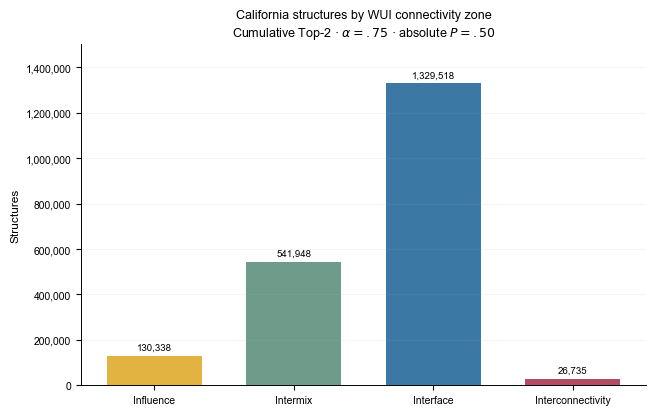

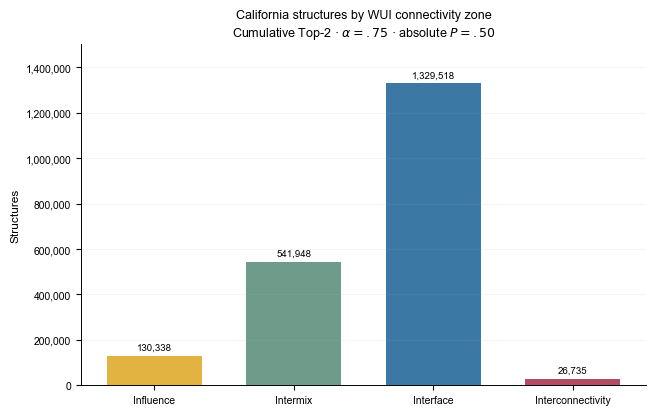

In [79]:
# Mutually exclusive statewide counts for the three mapped classes and
# CTop2 alpha=.75 Interconnectivity outside mapped WUI.
import shapely

WUI_CLASS_CACHE = DERIVED / 'california_building_wui_class.parquet'
if WUI_CLASS_CACHE.exists():
    building_wui = pd.read_parquet(WUI_CLASS_CACHE)
else:
    state_centroids = pd.read_parquet(STATE_CENTROIDS)
    class_labels = np.full(
        len(state_centroids), 'Outside mapped WUI', dtype=object,
    )
    # Later classes overwrite earlier ones to enforce the stated priority.
    for wui_name in ('Influence', 'Intermix', 'Interface'):
        class_geometry = wui_classes[wui_name].geometry.union_all()
        shapely.prepare(class_geometry)
        class_labels[shapely.intersects_xy(
            class_geometry,
            state_centroids.x.to_numpy(), state_centroids.y.to_numpy(),
        )] = wui_name
    building_wui = pd.DataFrame({
        'building_id': state_centroids.building_id.to_numpy(),
        'wui_class': class_labels,
    })
    building_wui.to_parquet(
        WUI_CLASS_CACHE, index=False, compression='zstd',
    )

assignments = pd.read_parquet(
    top2_paths['assignments'],
    columns=['building_id', 'component_id', 'component_size'],
).merge(building_wui, on='building_id', how='left', validate='one_to_one')
interface_component_ids = assignments.loc[
    assignments.wui_class.eq('Interface')
    & assignments.component_size.ge(2),
    'component_id',
].unique()
is_interconnectivity = (
    assignments.wui_class.eq('Outside mapped WUI')
    & assignments.component_size.ge(2)
    & assignments.component_id.isin(interface_component_ids)
)

ZONE_ORDER = ['Influence', 'Intermix', 'Interface', 'Interconnectivity']
zone_counts = pd.DataFrame({
    'zone': ZONE_ORDER,
    'structures': [
        int(assignments.wui_class.eq('Influence').sum()),
        int(assignments.wui_class.eq('Intermix').sum()),
        int(assignments.wui_class.eq('Interface').sum()),
        int(is_interconnectivity.sum()),
    ],
})
zone_counts['share_of_statewide_sample'] = (
    zone_counts.structures / len(assignments)
)
zone_counts['F_ij_threshold'] = F_2D_ABSOLUTE_P50
zone_counts['edge_floor_alpha'] = TOP2_EDGE_FLOOR_ALPHA
zone_counts.to_csv(
    RESULTS / 'california_structure_counts_by_wui_and_interconnectivity_ctop2_alpha075_p50.csv',
    index=False,
)

zone_colors = ['#E3B341', '#6F9B8A', '#3B78A3', '#B24C63']
fig_z, ax_z = plt.subplots(figsize=(6.6, 4.2))
bars = ax_z.bar(zone_counts.zone, zone_counts.structures, color=zone_colors,
                width=.68, edgecolor='none')
ax_z.bar_label(bars, labels=[f'{value:,}' for value in zone_counts.structures],
               padding=3, fontsize=7)
ax_z.set(
    ylabel='Structures',
    title='California structures by WUI connectivity zone\n'
          r'Cumulative Top-2 · $\alpha=.75$ · absolute $P=.50$',
)
ax_z.set_ylim(0, zone_counts.structures.max() * 1.13)
ax_z.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:,.0f}'))
ax_z.grid(axis='y', alpha=.18, linewidth=.5)
ax_z.spines[['top', 'right']].set_visible(False)
fig_z.tight_layout()
zone_stem = FIGURES / 'carsen_california_wui_interconnectivity_counts_ctop2_alpha075_p50'
fig_z.savefig(zone_stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white')
fig_z.savefig(zone_stem.with_suffix('.png'), dpi=600, bbox_inches='tight', facecolor='white')
display(zone_counts)
print('saved', zone_stem.with_suffix('.png'))
fig_z


## Connectivity distribution within each WUI zone

For each zone, the survival curve reports the share of its structures belonging to a full statewide SEN of at least the stated size. SEN size includes every building in the component regardless of WUI class; the four curves differ only in which structures form the denominator. Interconnectivity remains restricted to buildings outside mapped WUI whose SEN touches the existing Interface.

,zone,structures,components_represented,largest_sen,share_in_sen_ge_2,share_in_sen_ge_10,share_in_sen_ge_50
0,Influence,130338,106156,68,0.2782,0.0350,0.0006
1,Intermix,541948,454330,55,0.2660,0.0139,0.0001
2,Interface,1329518,883111,61,0.5064,0.0514,0.0003
3,Interconnectivity,26735,10682,61,1.0000,0.3416,0.0017


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/s2s_nc/main/california_wui_all_3mi_osm_2d/carsen_california_wui_zone_component_profiles_ctop2_alpha075_p50.png


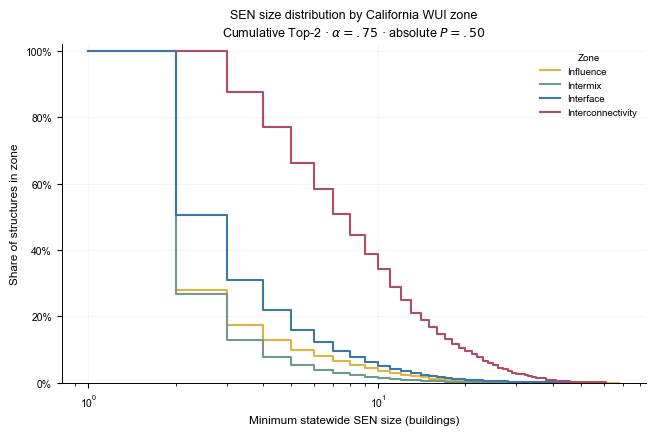

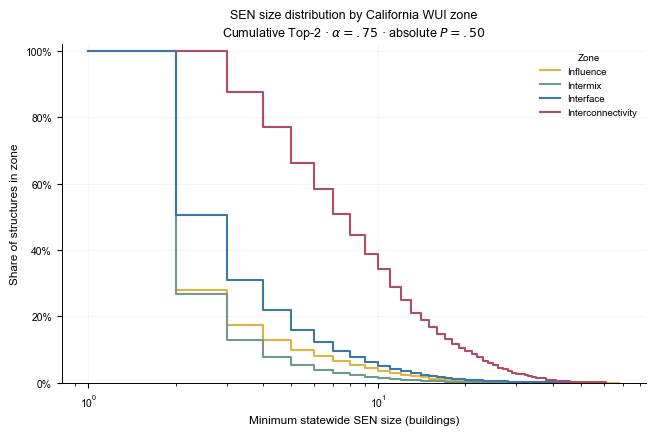

In [24]:
from matplotlib.ticker import PercentFormatter

assignments['analysis_zone'] = assignments.wui_class.where(
    assignments.wui_class.isin(ZONE_ORDER[:-1])
)
assignments.loc[is_interconnectivity, 'analysis_zone'] = 'Interconnectivity'

profile_rows = []
summary_rows = []
for zone in ZONE_ORDER:
    members = assignments.loc[
        assignments.analysis_zone.eq(zone),
        ['component_id', 'component_size'],
    ]
    frequency = (
        members.component_size.value_counts().sort_index()
        .rename_axis('sen_size')
        .reset_index(name='structures')
    )
    frequency['share_of_zone_at_least'] = (
        frequency.structures.iloc[::-1].cumsum().iloc[::-1]
        / len(members)
    )
    frequency.insert(0, 'zone', zone)
    profile_rows.append(frequency)
    summary_rows.append({
        'zone': zone,
        'structures': len(members),
        'components_represented': members.component_id.nunique(),
        'largest_sen': int(members.component_size.max()),
        'share_in_sen_ge_2': float(members.component_size.ge(2).mean()),
        'share_in_sen_ge_10': float(members.component_size.ge(10).mean()),
        'share_in_sen_ge_50': float(members.component_size.ge(50).mean()),
    })

zone_component_profile = pd.concat(profile_rows, ignore_index=True)
zone_connectivity_summary = pd.DataFrame(summary_rows)
zone_component_profile.to_csv(
    RESULTS / 'california_wui_zone_component_size_profiles_ctop2_alpha075_p50.csv',
    index=False,
)
zone_connectivity_summary.to_csv(
    RESULTS / 'california_wui_zone_connectivity_summary_ctop2_alpha075_p50.csv',
    index=False,
)

fig_p, ax_p = plt.subplots(figsize=(6.6, 4.4))
for zone, color in zip(ZONE_ORDER, zone_colors):
    curve = zone_component_profile.loc[
        zone_component_profile.zone.eq(zone)
    ]
    ax_p.step(
        curve.sen_size, curve.share_of_zone_at_least,
        where='post', lw=1.5, color=color, label=zone,
    )
ax_p.set(
    xscale='log', ylim=(0, 1.02),
    xlabel='Minimum statewide SEN size (buildings)',
    ylabel='Share of structures in zone',
    title='SEN size distribution by California WUI zone\n'
          r'Cumulative Top-2 · $\alpha=.75$ · absolute $P=.50$',
)
ax_p.yaxis.set_major_formatter(PercentFormatter(1))
ax_p.grid(alpha=.18, linewidth=.5)
ax_p.spines[['top', 'right']].set_visible(False)
ax_p.legend(frameon=False, fontsize=7, title='Zone', title_fontsize=7)
fig_p.tight_layout()
profile_stem = FIGURES / 'carsen_california_wui_zone_component_profiles_ctop2_alpha075_p50'
fig_p.savefig(profile_stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white')
fig_p.savefig(profile_stem.with_suffix('.png'), dpi=600, bbox_inches='tight', facecolor='white')
display(zone_connectivity_summary.round(4))
print('saved', profile_stem.with_suffix('.png'))
fig_p


## Network-size bins by fire-hazard severity and WUI zone

The statewide WUI25 parquet supplies the mapped WUI class but not a severity attribute: `gridcode` encodes Intermix, Influence, Not WUI, and Interface. Fire-hazard severity is therefore joined independently from CAL FIRE's matching official 2024 SRA and 2025 LRA Fire Hazard Severity Zone layers. Each structure is counted by the size of its full statewide cumulative Top-2 SEN ($\alpha=0.75$, absolute P50). The tables report both structures and distinct SENs represented in each cell; a SEN may be represented in more than one severity or WUI class.

,severity,network_size_bin,building_count,sen_count,share_within_class
0,Not classified,1,36304,36304,0.659413
1,Not classified,2–4,12232,5176,0.222178
2,Not classified,5–9,3828,644,0.069530
3,Not classified,10–24,2044,164,0.037127
4,Not classified,25–99,647,21,0.011752
5,Not classified,100–499,0,0,0.000000
6,Not classified,500+,0,0,0.000000
7,NonWildland,1,1955170,1955170,0.386435
8,NonWildland,2–4,1889811,771850,0.373517
9,NonWildland,5–9,755998,122904,0.149421


,analysis_zone,network_size_bin,building_count,sen_count,share_within_class
0,Influence,1,94073,94073,0.721762
1,Influence,2–4,23476,10108,0.180116
2,Influence,5–9,8233,1523,0.063167
3,Influence,10–24,4172,432,0.032009
4,Influence,25–99,384,20,0.002946
5,Influence,100–499,0,0,0.000000
6,Influence,500+,0,0,0.000000
7,Intermix,1,397792,397792,0.734004
8,Intermix,2–4,115542,51643,0.213198
9,Intermix,5–9,21086,4090,0.038908


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/s2s_nc/main/california_wui_all_3mi_osm_2d/carsen_california_network_size_bins_fhsz_wui_ctop2_alpha075_p50.png


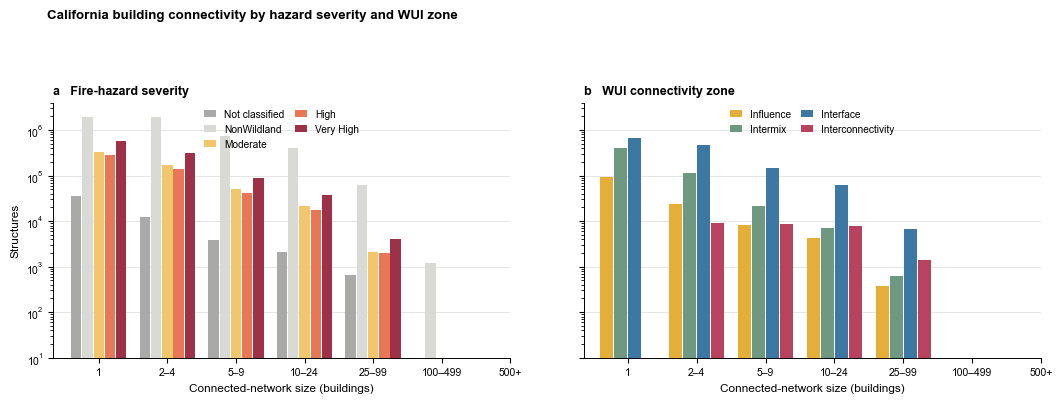

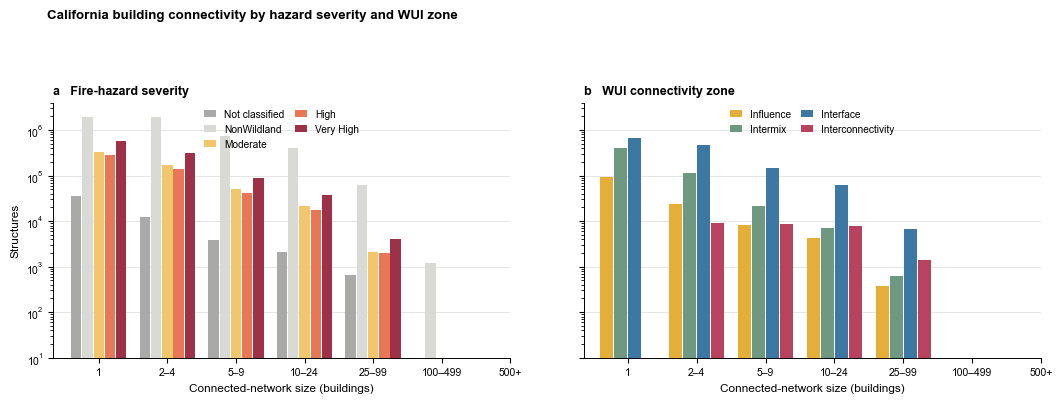

In [25]:
from concurrent.futures import ThreadPoolExecutor
import pyarrow.parquet as pq
import requests

CA_WUI25_SOURCE = Path(os.environ.get(
    'CALFIRE_CA_WUI25_PARQUET',
    '/Users/adamswietek/Documents/PostDoc/data/raw_la/fire/'
    '20260728T155639Z_b866/part-00000.parquet',
))
FHSZ_POLYGON_CACHE = DERIVED / 'california_fhsz_2024_2025.parquet'
FHSZ_BUILDING_CACHE = DERIVED / 'california_building_fhsz_2024_2025.parquet'
FHSZ_SERVICES = {
    'LRA': (
        'https://services1.arcgis.com/jUJYIo9tSA7EHvfZ/arcgis/rest/'
        'services/FHSALRA25_v1_All/FeatureServer/0/query'
    ),
    'SRA': (
        'https://services1.arcgis.com/jUJYIo9tSA7EHvfZ/arcgis/rest/'
        'services/FHSZSRA_23_3/FeatureServer/0/query'
    ),
}

if CA_WUI25_SOURCE.exists():
    wui25_schema = set(pq.ParquetFile(CA_WUI25_SOURCE).schema_arrow.names)
    assert {'gridcode', 'WUI_DESC', 'Shape'}.issubset(wui25_schema)
    assert not {'HAZ_NUM', 'HAZ_DESC'}.intersection(wui25_schema), (
        'The WUI25 source unexpectedly changed; review severity handling.'
    )

def _download_fhsz_service(jurisdiction, service_url):
    count_response = requests.get(
        service_url, params={
            'where': '1=1', 'returnCountOnly': 'true', 'f': 'json',
        }, timeout=180,
    )
    count_response.raise_for_status()
    count = int(count_response.json()['count'])

    def fetch_page(offset):
        response = requests.get(
            service_url, params={
                'where': '1=1',
                'outFields': 'FHSZ,FHSZ_Description',
                'returnGeometry': 'true',
                'outSR': '3310',
                'f': 'geojson',
                'resultOffset': offset,
                'resultRecordCount': 2000,
                'orderByFields': 'OBJECTID',
            }, timeout=240,
        )
        response.raise_for_status()
        return response.json().get('features', [])

    offsets = range(0, count, 2000)
    with ThreadPoolExecutor(max_workers=6) as executor:
        feature_pages = list(executor.map(fetch_page, offsets))
    features = [feature for page in feature_pages for feature in page]
    frame = gpd.GeoDataFrame.from_features(features, crs='EPSG:3310')
    frame['jurisdiction'] = jurisdiction
    return frame[['FHSZ', 'FHSZ_Description', 'jurisdiction', 'geometry']]

if FHSZ_POLYGON_CACHE.exists():
    fhsz = gpd.read_parquet(FHSZ_POLYGON_CACHE)
else:
    fhsz = gpd.GeoDataFrame(pd.concat([
        _download_fhsz_service(jurisdiction, service_url)
        for jurisdiction, service_url in FHSZ_SERVICES.items()
    ], ignore_index=True), geometry='geometry', crs='EPSG:3310')
    fhsz.to_parquet(FHSZ_POLYGON_CACHE, index=False, compression='zstd')

SEVERITY_ORDER = [
    'Not classified', 'NonWildland', 'Moderate', 'High', 'Very High',
]
if FHSZ_BUILDING_CACHE.exists():
    building_severity = pd.read_parquet(FHSZ_BUILDING_CACHE)
else:
    state_centroids = pd.read_parquet(STATE_CENTROIDS)
    severity_labels = np.full(
        len(state_centroids), 'Not classified', dtype=object,
    )
    for severity in SEVERITY_ORDER[1:]:
        severity_geometry = fhsz.loc[
            fhsz.FHSZ_Description.eq(severity), 'geometry'
        ].union_all()
        shapely.prepare(severity_geometry)
        severity_labels[shapely.intersects_xy(
            severity_geometry,
            state_centroids.x.to_numpy(), state_centroids.y.to_numpy(),
        )] = severity
    building_severity = pd.DataFrame({
        'building_id': state_centroids.building_id.to_numpy(),
        'severity': severity_labels,
    })
    building_severity.to_parquet(
        FHSZ_BUILDING_CACHE, index=False, compression='zstd',
    )

network_bins = [1, 2, 5, 10, 25, 100, 500, np.inf]
NETWORK_BIN_ORDER = [
    '1', '2–4', '5–9', '10–24', '25–99', '100–499', '500+',
]
network_classified = assignments.merge(
    building_severity, on='building_id', how='left', validate='one_to_one',
)
network_classified['network_size_bin'] = pd.cut(
    network_classified.component_size, bins=network_bins, right=False,
    labels=NETWORK_BIN_ORDER, ordered=True,
)
network_classified['severity'] = pd.Categorical(
    network_classified.severity.fillna('Not classified'),
    categories=SEVERITY_ORDER, ordered=True,
)
network_classified['analysis_zone'] = pd.Categorical(
    network_classified.analysis_zone, categories=ZONE_ORDER, ordered=True,
)

def binned_counts(frame, class_column, class_order):
    complete_index = pd.MultiIndex.from_product(
        [class_order, NETWORK_BIN_ORDER],
        names=[class_column, 'network_size_bin'],
    )
    summary = (
        frame.groupby([class_column, 'network_size_bin'], observed=True)
        .agg(
            building_count=('building_id', 'size'),
            sen_count=('component_id', 'nunique'),
        )
        .reindex(complete_index, fill_value=0)
        .reset_index()
    )
    totals = summary.groupby(class_column).building_count.transform('sum')
    summary['share_within_class'] = np.divide(
        summary.building_count, totals,
        out=np.zeros(len(summary), dtype=float), where=totals.gt(0),
    )
    return summary

severity_bin_counts = binned_counts(
    network_classified, 'severity', SEVERITY_ORDER,
)
zone_bin_counts = binned_counts(
    network_classified.dropna(subset=['analysis_zone']),
    'analysis_zone', ZONE_ORDER,
)
severity_bin_counts.to_csv(
    RESULTS / 'california_network_size_bins_by_fhsz_ctop2_alpha075_p50.csv',
    index=False,
)
zone_bin_counts.to_csv(
    RESULTS / 'california_network_size_bins_by_wui_zone_ctop2_alpha075_p50.csv',
    index=False,
)

SEVERITY_COLORS = {
    'Not classified': '#A9AAA7',
    'NonWildland': '#D9D9D6',
    'Moderate': '#F2C66D',
    'High': '#E77755',
    'Very High': '#9D3148',
}
ZONE_COLORS = {
    'Influence': '#E5AE38',
    'Intermix': '#6F9880',
    'Interface': '#3B78A3',
    'Interconnectivity': '#B7435E',
}

def grouped_count_bars(ax, summary, class_column, class_order, colors):
    x = np.arange(len(NETWORK_BIN_ORDER))
    group_width = .82
    bar_width = group_width / len(class_order)
    for index, category in enumerate(class_order):
        values = (summary.loc[summary[class_column].eq(category)]
                  .set_index('network_size_bin')
                  .reindex(NETWORK_BIN_ORDER).building_count
                  .fillna(0).to_numpy())
        positions = x - group_width / 2 + bar_width * (index + .5)
        ax.bar(
            positions, np.where(values > 0, values, np.nan),
            width=bar_width * .92, color=colors[category],
            label=category, linewidth=0, rasterized=True,
        )
    ax.set_xticks(x, NETWORK_BIN_ORDER)
    ax.set_yscale('log')
    ax.set_ylim(10, 4_000_000)
    ax.set_xlabel('Connected-network size (buildings)')
    ax.grid(axis='y', which='major', color='#D7D7D3', linewidth=.45)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

fig_h, axes_h = plt.subplots(1, 2, figsize=(10.8, 4.25), sharey=True)
grouped_count_bars(
    axes_h[0], severity_bin_counts, 'severity',
    SEVERITY_ORDER, SEVERITY_COLORS,
)
grouped_count_bars(
    axes_h[1], zone_bin_counts, 'analysis_zone',
    ZONE_ORDER, ZONE_COLORS,
)
axes_h[0].set_title('a   Fire-hazard severity', loc='left', fontweight='bold')
axes_h[1].set_title('b   WUI connectivity zone', loc='left', fontweight='bold')
axes_h[0].set_ylabel('Structures')
axes_h[0].legend(
    loc='upper center', bbox_to_anchor=(.5, 1.01),
    frameon=False, ncol=2, columnspacing=1.0, handlelength=1.2,
)
axes_h[1].legend(
    loc='upper center', bbox_to_anchor=(.5, 1.01),
    frameon=False, ncol=2, columnspacing=1.0, handlelength=1.2,
)
fig_h.suptitle(
    'California building connectivity by hazard severity and WUI zone',
    x=.07, ha='left', fontweight='bold',
)
fig_h.subplots_adjust(left=.075, right=.99, top=.76, bottom=.16, wspace=.16)
hazard_stem = (
    FIGURES / 'carsen_california_network_size_bins_fhsz_wui_ctop2_alpha075_p50'
)
fig_h.savefig(hazard_stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white')
fig_h.savefig(hazard_stem.with_suffix('.png'), dpi=600, bbox_inches='tight', facecolor='white')
display(severity_bin_counts)
display(zone_bin_counts)
print('saved', hazard_stem.with_suffix('.png'))
fig_h


,major_region,minimum_sen_size,structures_in_large_sens,sens_represented,largest_sen,high_or_very_high_structures,share_of_high_or_very_high_structures
0,Southern California,10,51252,4129,61,990703,0.0517
1,Central California,10,3774,279,59,153611,0.0246
2,Northern California,10,5168,461,41,372861,0.0139
3,Southern California,25,4810,185,61,990703,0.0049
4,Central California,25,777,25,59,153611,0.0051
5,Northern California,25,426,18,41,372861,0.0011


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/s2s_nc/main/california_wui_all_3mi_osm_2d/carsen_california_high_very_high_fhsz_large_sens_by_major_region_ctop2_alpha075_p50.png


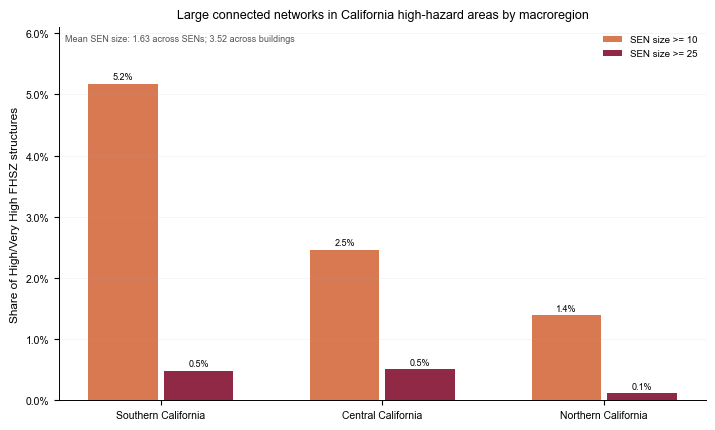

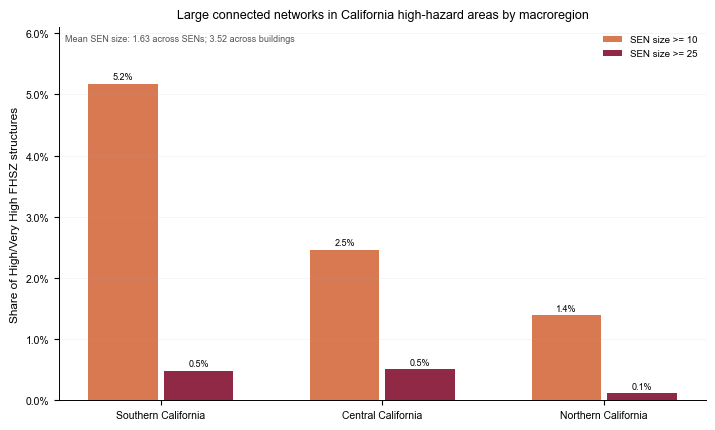

In [26]:
# High/Very High FHSZ structures in larger-than-average SENs, by macroregion.
# These transparent latitude bands are descriptive, not administrative regions:
# Southern < 35.0°N; Central 35.0–37.5°N; Northern >= 37.5°N.
from pyproj import Transformer

REGION_ORDER = ['Southern California', 'Central California', 'Northern California']
LARGE_SEN_THRESHOLDS = [10, 25]

high_hazard = network_classified.loc[
    network_classified.severity.isin(['High', 'Very High']),
    ['building_id', 'component_id', 'component_size'],
].merge(
    pd.read_parquet(STATE_CENTROIDS, columns=['building_id', 'x', 'y']),
    on='building_id', how='left', validate='one_to_one',
)
to_wgs84 = Transformer.from_crs(3310, 4326, always_xy=True)
_, high_hazard['latitude'] = to_wgs84.transform(
    high_hazard.x.to_numpy(), high_hazard.y.to_numpy(),
)
high_hazard['major_region'] = pd.cut(
    high_hazard.latitude, bins=[-np.inf, 35.0, 37.5, np.inf],
    labels=REGION_ORDER, right=False, ordered=True,
)

region_denominators = (
    high_hazard.groupby('major_region', observed=False)
    .size().rename('high_or_very_high_structures')
)
regional_large_sen_rows = []
for threshold in LARGE_SEN_THRESHOLDS:
    qualifying = high_hazard.loc[high_hazard.component_size.ge(threshold)]
    summary = (
        qualifying.groupby('major_region', observed=False)
        .agg(
            structures_in_large_sens=('building_id', 'size'),
            sens_represented=('component_id', 'nunique'),
            largest_sen=('component_size', 'max'),
        )
        .join(region_denominators).reset_index()
    )
    summary.insert(1, 'minimum_sen_size', threshold)
    summary['share_of_high_or_very_high_structures'] = (
        summary.structures_in_large_sens
        / summary.high_or_very_high_structures
    )
    regional_large_sen_rows.append(summary)
regional_high_hazard_large_sens = pd.concat(
    regional_large_sen_rows, ignore_index=True,
)
regional_high_hazard_large_sens.to_csv(
    RESULTS / 'california_high_very_high_fhsz_large_sens_by_major_region_ctop2_alpha075_p50.csv',
    index=False,
)

distinct_sens = network_classified[[
    'component_id', 'component_size',
]].drop_duplicates('component_id')
mean_sen_size = distinct_sens.component_size.mean()
building_weighted_mean_sen_size = network_classified.component_size.mean()

fig_r, ax_r = plt.subplots(figsize=(7.2, 4.35))
x = np.arange(len(REGION_ORDER))
width = .34
threshold_colors = ['#D97952', '#8F2945']
for index, (threshold, color) in enumerate(zip(
    LARGE_SEN_THRESHOLDS, threshold_colors,
)):
    plot_rows = (
        regional_high_hazard_large_sens.loc[
            regional_high_hazard_large_sens.minimum_sen_size.eq(threshold)
        ].set_index('major_region').reindex(REGION_ORDER)
    )
    positions = x + (index - .5) * width
    bars = ax_r.bar(
        positions, plot_rows.share_of_high_or_very_high_structures,
        width=width * .92, color=color, label=f'SEN size >= {threshold}',
    )
    ax_r.bar_label(
        bars, labels=[f'{value:.1%}' for value in bars.datavalues],
        padding=2, fontsize=6.5,
    )
ax_r.set(
    xticks=x, xticklabels=REGION_ORDER,
    ylabel='Share of High/Very High FHSZ structures',
    title='Large connected networks in California high-hazard areas by macroregion',
)
ax_r.yaxis.set_major_formatter(PercentFormatter(1))
ax_r.set_ylim(0, max(
    .01, regional_high_hazard_large_sens.share_of_high_or_very_high_structures.max() * 1.18,
))
ax_r.grid(axis='y', alpha=.18, linewidth=.5)
ax_r.spines[['top', 'right']].set_visible(False)
ax_r.legend(frameon=False, fontsize=7)
ax_r.text(
    .01, .98,
    f'Mean SEN size: {mean_sen_size:.2f} across SENs; '
    f'{building_weighted_mean_sen_size:.2f} across buildings',
    transform=ax_r.transAxes, ha='left', va='top', fontsize=6.5, color='#555555',
)
fig_r.tight_layout()
regional_hazard_stem = (
    FIGURES / 'carsen_california_high_very_high_fhsz_large_sens_by_major_region_ctop2_alpha075_p50'
)
fig_r.savefig(
    regional_hazard_stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white',
)
fig_r.savefig(
    regional_hazard_stem.with_suffix('.png'), dpi=600,
    bbox_inches='tight', facecolor='white',
)
display(regional_high_hazard_large_sens.round({
    'share_of_high_or_very_high_structures': 4,
}))
print('saved', regional_hazard_stem.with_suffix('.png'))
fig_r


## Connected-network size versus outward depth from the Influence zone

This diagnostic uses the statewide cumulative Top-2 network at the absolute P50 threshold with $\alpha=0.75$. It retains Interface-connected components that include at least one building outside all mapped-WUI classes. For every outside-WUI building, depth is its shortest centroid distance to the mapped Influence-zone polygons; component depth is the maximum of those distances. Network size remains the full statewide component size, including members inside and outside mapped WUI. Points show individual SENs; the overlaid median and interquartile range summarize successive distance bands.

,components,outside_wui_buildings,median_maximum_depth_miles,p90_maximum_depth_miles,maximum_depth_miles,largest_component,spearman_depth_vs_size
0,10682,26735,0.3026,0.7398,7.1485,61,0.0261


,distance_band,median,q25,q75,components
0,0–0.25,3.0,2.0,6.0,4302
1,0.25–0.5,4.0,2.0,6.0,3742
2,0.5–1,4.0,2.0,6.0,2085
3,1–2,4.0,2.0,6.0,520
4,2–3,4.5,2.0,8.0,30


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/s2s_nc/main/california_wui_all_3mi_osm_2d/carsen_california_ctop2_alpha075_size_vs_influence_depth_p50.png


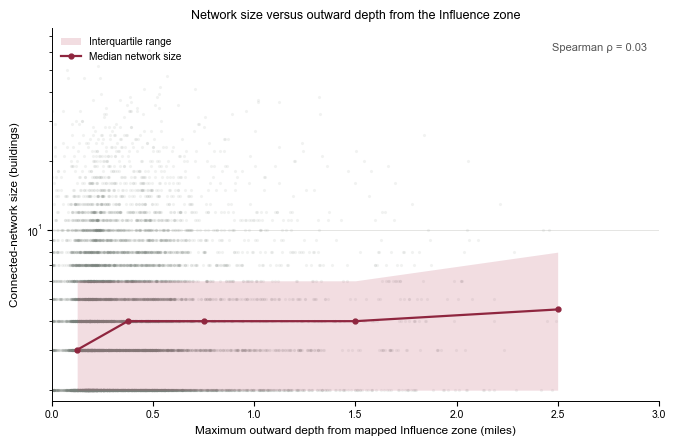

In [27]:
INFLUENCE_DEPTH_CACHE = (
    DERIVED / 'california_ctop2_alpha075_component_influence_depth.parquet'
)
if INFLUENCE_DEPTH_CACHE.exists():
    component_depth = pd.read_parquet(INFLUENCE_DEPTH_CACHE)
else:
    outside_members = assignments.loc[
        is_interconnectivity,
        ['building_id', 'component_id', 'component_size'],
    ].copy()
    with duckdb.connect() as con:
        con.register('outside_members', outside_members)
        outside_coordinates = con.execute(
            '''
            SELECT o.building_id, o.component_id, o.component_size, c.x, c.y
            FROM outside_members o
            JOIN read_parquet(?) c USING (building_id)
            ''',
            [str(STATE_CENTROIDS)],
        ).fetchdf()
    outside_points = gpd.GeoDataFrame(
        outside_coordinates,
        geometry=gpd.points_from_xy(
            outside_coordinates.x, outside_coordinates.y,
        ),
        crs='EPSG:3310',
    )
    influence_polygons = gpd.GeoDataFrame(
        geometry=wui_classes['Influence'].geometry,
        crs=wui_classes['Influence'].crs,
    )
    nearest_influence = gpd.sjoin_nearest(
        outside_points, influence_polygons,
        how='left', distance_col='depth_from_influence_m',
    )
    # Equidistant polygons can duplicate a point; retain one minimum distance.
    building_depth = (
        nearest_influence.groupby(
            ['building_id', 'component_id', 'component_size'],
            as_index=False, observed=True,
        ).depth_from_influence_m.min()
    )
    component_depth = (
        building_depth.groupby('component_id', as_index=False)
        .agg(
            component_size=('component_size', 'first'),
            outside_wui_buildings=('building_id', 'nunique'),
            maximum_depth_m=('depth_from_influence_m', 'max'),
            median_depth_m=('depth_from_influence_m', 'median'),
            mean_depth_m=('depth_from_influence_m', 'mean'),
        )
    )
    component_depth.to_parquet(
        INFLUENCE_DEPTH_CACHE, index=False, compression='zstd',
    )

component_depth['maximum_depth_miles'] = (
    component_depth.maximum_depth_m / 1609.344
)
depth_summary = pd.DataFrame([{
    'components': len(component_depth),
    'outside_wui_buildings': int(component_depth.outside_wui_buildings.sum()),
    'median_maximum_depth_miles': component_depth.maximum_depth_miles.median(),
    'p90_maximum_depth_miles': component_depth.maximum_depth_miles.quantile(.90),
    'maximum_depth_miles': component_depth.maximum_depth_miles.max(),
    'largest_component': int(component_depth.component_size.max()),
    'spearman_depth_vs_size': component_depth[[
        'maximum_depth_miles', 'component_size'
    ]].rank().corr().iloc[0, 1],
}])
component_depth.to_csv(
    RESULTS / 'california_ctop2_alpha075_component_influence_depth_p50.csv',
    index=False,
)
depth_summary.to_csv(
    RESULTS / 'california_ctop2_alpha075_component_influence_depth_summary_p50.csv',
    index=False,
)

fig_d, ax_d = plt.subplots(figsize=(6.8, 4.5))
plot_depth_limit_miles = 3.0
plotted_depth = component_depth.loc[
    component_depth.maximum_depth_miles.le(plot_depth_limit_miles)
]
components_beyond_plot = int(
    component_depth.maximum_depth_miles.gt(plot_depth_limit_miles).sum()
)
ax_d.scatter(
    plotted_depth.maximum_depth_miles, plotted_depth.component_size,
    s=5, color='#79827C', alpha=.10, linewidth=0, rasterized=True,
)
distance_edges = [0, .25, .5, 1, 2, 3]
distance_labels = ['0–0.25', '0.25–0.5', '0.5–1', '1–2', '2–3']
distance_midpoints = np.array([.125, .375, .75, 1.5, 2.5])
plotted_depth = plotted_depth.copy()
plotted_depth['distance_band'] = pd.cut(
    plotted_depth.maximum_depth_miles, distance_edges,
    labels=distance_labels, include_lowest=True, right=False,
)
distance_trend = (
    plotted_depth.groupby('distance_band', observed=False).component_size
    .agg(
        median='median',
        q25=lambda values: values.quantile(.25),
        q75=lambda values: values.quantile(.75),
        components='size',
    ).reset_index()
)
distance_trend.to_csv(
    RESULTS / 'california_ctop2_alpha075_influence_depth_bins_p50.csv',
    index=False,
)
ax_d.fill_between(
    distance_midpoints, distance_trend.q25, distance_trend.q75,
    color='#B7435E', alpha=.18, linewidth=0, label='Interquartile range',
)
ax_d.plot(
    distance_midpoints, distance_trend['median'],
    color='#8F263F', linewidth=1.6, marker='o', markersize=3.5,
    label='Median network size',
)
ax_d.set(
    xlabel='Maximum outward depth from mapped Influence zone (miles)',
    ylabel='Connected-network size (buildings)',
    title='Network size versus outward depth from the Influence zone',
)
ax_d.set_xlim(0, plot_depth_limit_miles)
ax_d.set_yscale('log')
ax_d.set_ylim(1.8, component_depth.component_size.max() * 1.25)
ax_d.text(
    .98, .96,
    f'Spearman ρ = {depth_summary.spearman_depth_vs_size.iloc[0]:.2f}',
    transform=ax_d.transAxes, ha='right', va='top', color='#555555',
)
ax_d.grid(axis='y', which='major', color='#D7D7D3', linewidth=.45)
ax_d.set_axisbelow(True)
ax_d.spines[['top', 'right']].set_visible(False)
ax_d.legend(frameon=False, loc='upper left')
fig_d.tight_layout()
depth_stem = (
    FIGURES / 'carsen_california_ctop2_alpha075_size_vs_influence_depth_p50'
)
fig_d.savefig(
    depth_stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white',
)
fig_d.savefig(
    depth_stem.with_suffix('.png'), dpi=600, bbox_inches='tight',
    facecolor='white',
)
display(depth_summary.round(4))
display(distance_trend)
print('saved', depth_stem.with_suffix('.png'))
plt.show()


## Candidate regional case studies across outward depth

Four relatively large components are selected near 0.25, 0.5, 1, and 2 miles while deliberately spreading the examples across the Bay Area, Central Coast, San Diego County, and Los Angeles. The selection favors component size within each depth neighborhood, then geographic diversity; it is not a random or statistically representative sample.

,case,region,component_id,target_depth_miles,maximum_depth_miles,depth_difference_miles,component_size,outside_wui_buildings,longitude,latitude
0,A,Daly City–Pacifica (Bay Area),2048799,0.25,0.237,-0.013,46,15,-122.4893,37.6735
1,B,San Luis Obispo (Central Coast),1573964,0.50,0.555,0.055,59,13,-120.6633,35.2791
2,C,Eastern Chula Vista–Otay (San Diego County),582967,1.00,1.018,0.018,37,31,-116.9922,32.6251
3,D,Sherman Oaks–Studio City (Los Angeles),18630,2.00,1.840,-0.160,26,15,-118.4304,34.1495


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/s2s_nc/main/california_wui_all_3mi_osm_2d/carsen_california_ctop2_alpha075_influence_depth_case_studies_p50.png


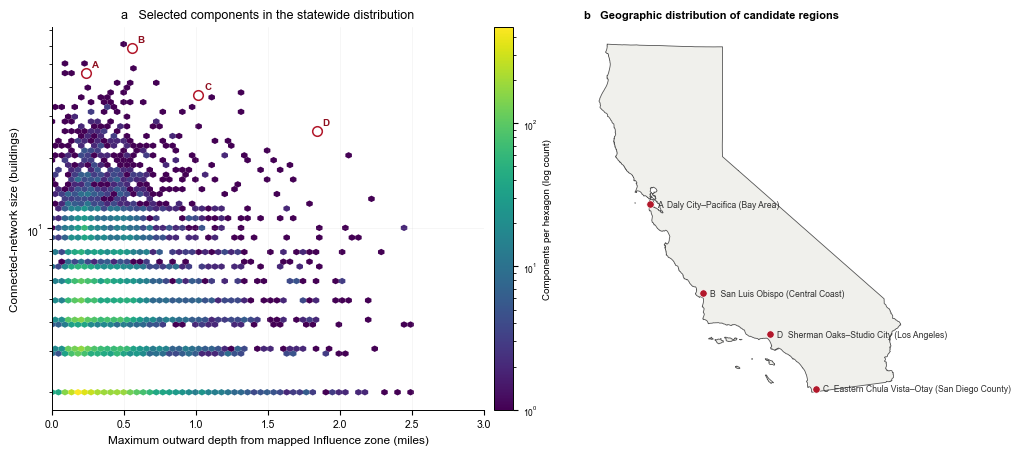

In [28]:
candidate_definitions = pd.DataFrame([
    {'case': 'A', 'component_id': 2048799, 'target_depth_miles': .25,
     'region': 'Daly City–Pacifica (Bay Area)'},
    {'case': 'B', 'component_id': 1573964, 'target_depth_miles': .50,
     'region': 'San Luis Obispo (Central Coast)'},
    {'case': 'C', 'component_id': 582967, 'target_depth_miles': 1.00,
     'region': 'Eastern Chula Vista–Otay (San Diego County)'},
    {'case': 'D', 'component_id': 18630, 'target_depth_miles': 2.00,
     'region': 'Sherman Oaks–Studio City (Los Angeles)'},
])
candidate_depth = pd.read_parquet(
    DERIVED / 'california_ctop2_alpha075_component_influence_depth.parquet'
)
candidate_depth['maximum_depth_miles'] = (
    candidate_depth.maximum_depth_m / 1609.344
)
component_centers = pd.read_parquet(
    SPATIAL_DIR / 'california_top2_component_spatial_summary.parquet',
    columns=['component_id', 'x', 'y', 'xmin', 'xmax', 'ymin', 'ymax'],
)
case_studies = (
    candidate_definitions
    .merge(candidate_depth, on='component_id', validate='one_to_one')
    .merge(component_centers, on='component_id', validate='one_to_one')
)
case_points = gpd.GeoDataFrame(
    case_studies.copy(),
    geometry=gpd.points_from_xy(case_studies.x, case_studies.y),
    crs='EPSG:3310',
)
case_wgs84 = case_points.to_crs(4326)
case_studies['longitude'] = case_wgs84.geometry.x.to_numpy()
case_studies['latitude'] = case_wgs84.geometry.y.to_numpy()
case_studies['depth_difference_miles'] = (
    case_studies.maximum_depth_miles - case_studies.target_depth_miles
)
case_table = case_studies[[
    'case', 'region', 'component_id', 'target_depth_miles',
    'maximum_depth_miles', 'depth_difference_miles', 'component_size',
    'outside_wui_buildings', 'longitude', 'latitude',
]].copy()
case_table.to_csv(
    RESULTS / 'california_ctop2_alpha075_influence_depth_case_studies_p50.csv',
    index=False,
)

all_depth = candidate_depth.loc[
    candidate_depth.maximum_depth_miles.le(3)
]
candidate_boundary, _ = load_california_context(CA_BOUNDARY, CA_WUI_CLASSES)
fig_cases, (ax_distribution, ax_locator) = plt.subplots(
    1, 2, figsize=(10.4, 4.6), gridspec_kw={'width_ratios': [1.55, 1]},
)
case_hexbin = ax_distribution.hexbin(
    all_depth.maximum_depth_miles, all_depth.component_size,
    gridsize=(55, 36), mincnt=1, bins='log', yscale='log',
    cmap='viridis', linewidths=0, rasterized=True,
)
ax_distribution.scatter(
    case_studies.maximum_depth_miles, case_studies.component_size,
    s=48, facecolor='white', edgecolor='#B2182B', linewidth=1.1, zorder=5,
)
for row in case_studies.itertuples():
    ax_distribution.annotate(
        row.case, (row.maximum_depth_miles, row.component_size),
        xytext=(4, 4), textcoords='offset points', fontsize=7,
        fontweight='bold', color='#8F1020', zorder=6,
    )
ax_distribution.set(
    xlim=(0, 3),
    xlabel='Maximum outward depth from mapped Influence zone (miles)',
    ylabel='Connected-network size (buildings)',
    title='a   Selected components in the statewide distribution',
)
ax_distribution.grid(alpha=.16, linewidth=.45)
ax_distribution.spines[['top', 'right']].set_visible(False)
case_cbar = fig_cases.colorbar(case_hexbin, ax=ax_distribution, pad=.02)
case_cbar.set_label('Components per hexagon (log count)', fontsize=7)
case_cbar.ax.tick_params(labelsize=6)

candidate_boundary.plot(
    ax=ax_locator, color='#F0F0EC', edgecolor='#555555', linewidth=.6,
)
case_points.plot(
    ax=ax_locator, color='#B2182B', edgecolor='white', linewidth=.45,
    markersize=28, zorder=3,
)
for row in case_points.itertuples():
    ax_locator.annotate(
        f'{row.case}  {row.region}', (row.geometry.x, row.geometry.y),
        xytext=(5, 0), textcoords='offset points', ha='left', va='center',
        fontsize=6.2, color='#303030',
    )
ax_locator.set_title(
    'b   Geographic distribution of candidate regions',
    loc='left', fontsize=8, fontweight='bold',
)
ax_locator.set_aspect('equal')
ax_locator.axis('off')
fig_cases.tight_layout(w_pad=1.8)
case_stem = (
    FIGURES / 'carsen_california_ctop2_alpha075_influence_depth_case_studies_p50'
)
fig_cases.savefig(
    case_stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white',
)
fig_cases.savefig(
    case_stem.with_suffix('.png'), dpi=600, bbox_inches='tight',
    facecolor='white',
)
display(case_table.round({
    'target_depth_miles': 2, 'maximum_depth_miles': 3,
    'depth_difference_miles': 3, 'longitude': 4, 'latitude': 4,
}))
print('saved', case_stem.with_suffix('.png'))
plt.show()


## Sierra and interior California alternatives

These alternatives emphasize geographic coverage along the Sierra and its foothills rather than matching the four original depth targets exactly. The statewide results do not contain a compelling large Sierra component near two miles: beyond roughly 1.3 miles, the plausible interior candidates contain only two to four buildings. The options below therefore favor interpretable component size and span the northern foothills, central Sierra, eastern Sierra, and southern Sierra.

,case,region,component_id,maximum_depth_miles,component_size,outside_wui_buildings,longitude,latitude
0,S1,Grass Valley (northern Sierra foothills),4006579,0.888,10,3,-121.0661,39.2212
1,S2,Lincoln–western Placer foothills,425468,0.204,37,27,-121.2703,38.8797
2,S3,Calaveras County foothills,963084,0.438,12,2,-120.6805,38.1967
3,S4,Bishop–eastern Sierra,3944922,0.279,15,12,-118.4195,37.3821
4,S5,Porterville–southern Sierra foothills,1656144,0.447,12,6,-119.0014,36.0494
5,S6,Tehachapi–southern Sierra,1895981,0.279,19,2,-118.4688,35.1216


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/s2s_nc/main/california_wui_all_3mi_osm_2d/carsen_california_ctop2_alpha075_sierra_depth_options_p50.png


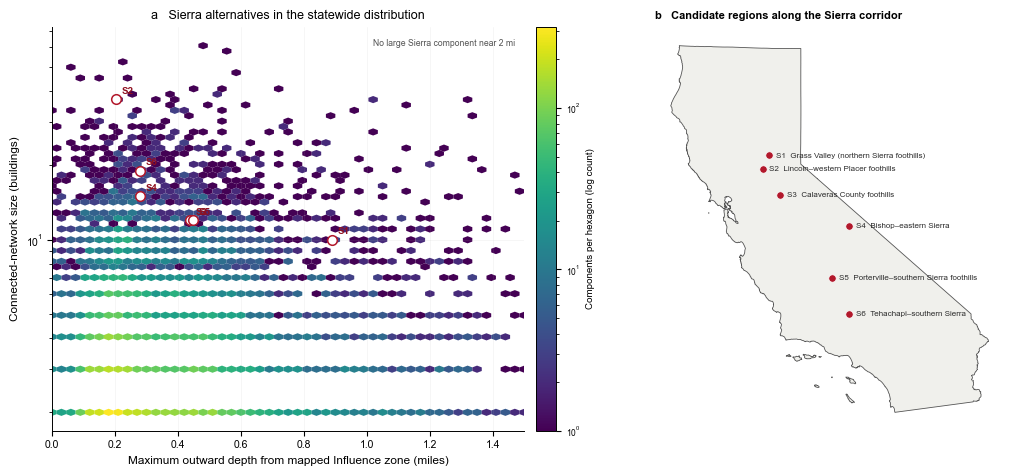

In [29]:
sierra_definitions = pd.DataFrame([
    {'case': 'S1', 'component_id': 4006579,
     'region': 'Grass Valley (northern Sierra foothills)'},
    {'case': 'S2', 'component_id': 425468,
     'region': 'Lincoln–western Placer foothills'},
    {'case': 'S3', 'component_id': 963084,
     'region': 'Calaveras County foothills'},
    {'case': 'S4', 'component_id': 3944922,
     'region': 'Bishop–eastern Sierra'},
    {'case': 'S5', 'component_id': 1656144,
     'region': 'Porterville–southern Sierra foothills'},
    {'case': 'S6', 'component_id': 1895981,
     'region': 'Tehachapi–southern Sierra'},
])
sierra_depth = pd.read_parquet(
    DERIVED / 'california_ctop2_alpha075_component_influence_depth.parquet'
)
sierra_depth['maximum_depth_miles'] = (
    sierra_depth.maximum_depth_m / 1609.344
)
sierra_centers = pd.read_parquet(
    SPATIAL_DIR / 'california_top2_component_spatial_summary.parquet',
    columns=['component_id', 'x', 'y'],
)
sierra_options = (
    sierra_definitions
    .merge(sierra_depth, on='component_id', validate='one_to_one')
    .merge(sierra_centers, on='component_id', validate='one_to_one')
)
sierra_points = gpd.GeoDataFrame(
    sierra_options.copy(),
    geometry=gpd.points_from_xy(sierra_options.x, sierra_options.y),
    crs='EPSG:3310',
)
sierra_wgs84 = sierra_points.to_crs(4326)
sierra_options['longitude'] = sierra_wgs84.geometry.x.to_numpy()
sierra_options['latitude'] = sierra_wgs84.geometry.y.to_numpy()
sierra_table = sierra_options[[
    'case', 'region', 'component_id', 'maximum_depth_miles',
    'component_size', 'outside_wui_buildings', 'longitude', 'latitude',
]].sort_values('latitude', ascending=False)
sierra_table.to_csv(
    RESULTS / 'california_ctop2_alpha075_sierra_influence_depth_options_p50.csv',
    index=False,
)

sierra_plot_depth = sierra_depth.loc[
    sierra_depth.maximum_depth_miles.le(1.5)
]
sierra_boundary, _ = load_california_context(CA_BOUNDARY, CA_WUI_CLASSES)
fig_sierra, (ax_sierra_dist, ax_sierra_map) = plt.subplots(
    1, 2, figsize=(10.4, 4.8), gridspec_kw={'width_ratios': [1.45, 1]},
)
sierra_hexbin = ax_sierra_dist.hexbin(
    sierra_plot_depth.maximum_depth_miles, sierra_plot_depth.component_size,
    gridsize=(50, 34), mincnt=1, bins='log', yscale='log',
    cmap='viridis', linewidths=0, rasterized=True,
)
ax_sierra_dist.scatter(
    sierra_options.maximum_depth_miles, sierra_options.component_size,
    s=48, facecolor='white', edgecolor='#B2182B', linewidth=1.1, zorder=5,
)
for row in sierra_options.itertuples():
    ax_sierra_dist.annotate(
        row.case, (row.maximum_depth_miles, row.component_size),
        xytext=(4, 4), textcoords='offset points', fontsize=7,
        fontweight='bold', color='#8F1020', zorder=6,
    )
ax_sierra_dist.set(
    xlim=(0, 1.5),
    xlabel='Maximum outward depth from mapped Influence zone (miles)',
    ylabel='Connected-network size (buildings)',
    title='a   Sierra alternatives in the statewide distribution',
)
ax_sierra_dist.text(
    .98, .97, 'No large Sierra component near 2 mi',
    transform=ax_sierra_dist.transAxes, ha='right', va='top',
    fontsize=6.2, color='#555555',
)
ax_sierra_dist.grid(alpha=.16, linewidth=.45)
ax_sierra_dist.spines[['top', 'right']].set_visible(False)
sierra_cbar = fig_sierra.colorbar(sierra_hexbin, ax=ax_sierra_dist, pad=.02)
sierra_cbar.set_label('Components per hexagon (log count)', fontsize=7)
sierra_cbar.ax.tick_params(labelsize=6)

sierra_boundary.plot(
    ax=ax_sierra_map, color='#F0F0EC', edgecolor='#555555', linewidth=.6,
)
sierra_points.plot(
    ax=ax_sierra_map, color='#B2182B', edgecolor='white', linewidth=.45,
    markersize=28, zorder=3,
)
for row in sierra_points.sort_values('y', ascending=False).itertuples():
    ax_sierra_map.annotate(
        f'{row.case}  {row.region}', (row.geometry.x, row.geometry.y),
        xytext=(5, 0), textcoords='offset points', ha='left', va='center',
        fontsize=5.8, color='#303030',
    )
ax_sierra_map.set_title(
    'b   Candidate regions along the Sierra corridor',
    loc='left', fontsize=8, fontweight='bold',
)
ax_sierra_map.set_aspect('equal')
ax_sierra_map.axis('off')
fig_sierra.tight_layout(w_pad=1.8)
sierra_stem = (
    FIGURES / 'carsen_california_ctop2_alpha075_sierra_depth_options_p50'
)
fig_sierra.savefig(
    sierra_stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white',
)
fig_sierra.savefig(
    sierra_stem.with_suffix('.png'), dpi=600, bbox_inches='tight',
    facecolor='white',
)
display(sierra_table.round({
    'maximum_depth_miles': 3, 'longitude': 4, 'latitude': 4,
}))
print('saved', sierra_stem.with_suffix('.png'))
plt.show()


## Statewide cluster size and coastal–interior connectivity atlas

Panel a summarizes cumulative Top-2 ($\alpha=0.75$) connected-network size across California. Panels b–d provide coastal examples from northern, central, and southern California; panels e–g provide northern, eastern, and southern interior examples. All buildings are shown within identically sized regional windows, and color is each building's full statewide component size, so clusters are never rebuilt within a crop. Black dots identify the selected communities consistently in the locator and insets, subtle mapped-WUI boundaries provide geographic context, and every panel shares the same logarithmic softened `RdYlBu_r` scale.

,case,displayed_buildings,displayed_components,largest_displayed_component,panel,setting,region,component_id,component_size,maximum_depth_miles
0,C1,126982,42726,80,b,Coastal,Daly City–Pacifica (Bay Area),2048799,46,0.237
1,C2,25036,15278,59,c,Coastal,San Luis Obispo (Central Coast),1573964,59,0.555
2,C3,60289,33865,48,d,Coastal,Eastern Chula Vista–Otay (San Diego County),582967,37,1.018
3,I1,12811,10880,26,e,Interior,Grass Valley (northern Sierra foothills),4006579,10,0.888
4,I2,5733,4194,19,f,Interior,Bishop–eastern Sierra,3944922,15,0.279
5,I3,4953,3507,20,g,Interior,Tehachapi–southern Sierra,1895981,19,0.279


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/s2s_nc/main/california_wui_all_3mi_osm_2d/carsen_california_ctop2_alpha075_coastal_interior_atlas_p50.png


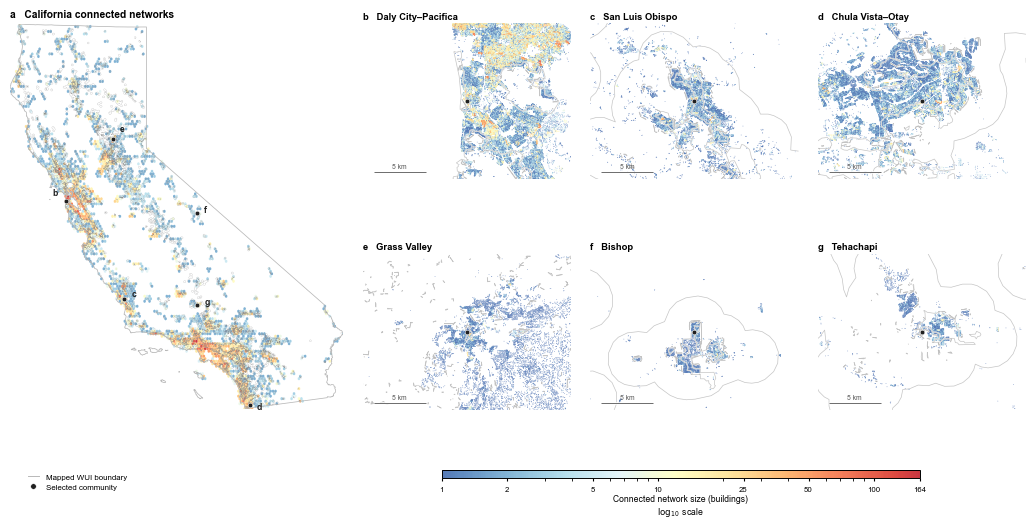

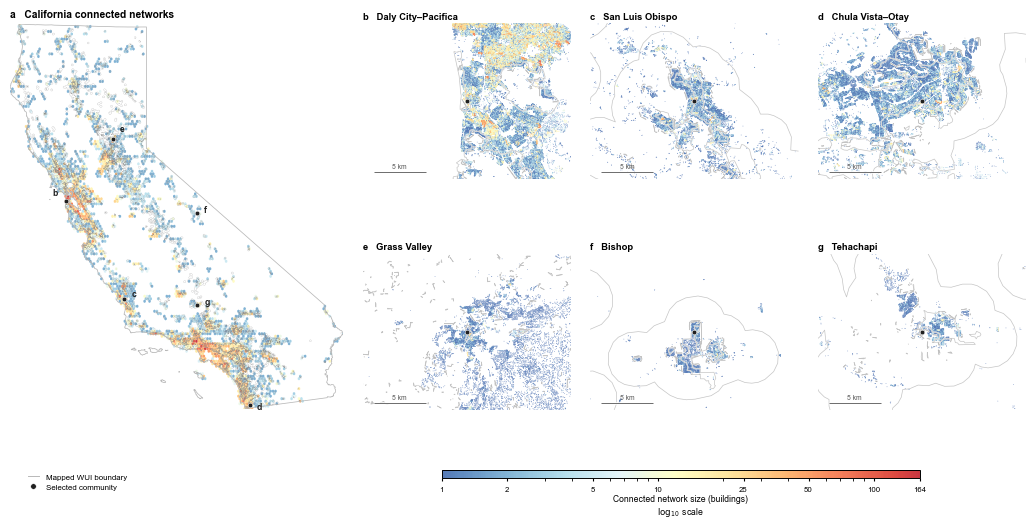

In [30]:
# Fixed, equal-scale regional windows make connectivity directly comparable.
REGIONAL_HALF_WIDTH_M = 10_000
REGIONAL_HALF_HEIGHT_M = 7_500
atlas_components = pd.read_parquet(
    SPATIAL_DIR / 'california_top2_component_spatial_summary.parquet',
    columns=[
        'component_id', 'component_size', 'x', 'y',
        'xmin', 'xmax', 'ymin', 'ymax',
    ],
)
atlas_definitions = pd.DataFrame([
    {'case': 'C1', 'component_id': 2048799, 'setting': 'Coastal',
     'region': 'Daly City–Pacifica (Bay Area)',
     'short_region': 'Daly City–Pacifica'},
    {'case': 'C2', 'component_id': 1573964, 'setting': 'Coastal',
     'region': 'San Luis Obispo (Central Coast)',
     'short_region': 'San Luis Obispo'},
    {'case': 'C3', 'component_id': 582967, 'setting': 'Coastal',
     'region': 'Eastern Chula Vista–Otay (San Diego County)',
     'short_region': 'Chula Vista–Otay'},
    {'case': 'I1', 'component_id': 4006579, 'setting': 'Interior',
     'region': 'Grass Valley (northern Sierra foothills)',
     'short_region': 'Grass Valley'},
    {'case': 'I2', 'component_id': 3944922, 'setting': 'Interior',
     'region': 'Bishop–eastern Sierra', 'short_region': 'Bishop'},
    {'case': 'I3', 'component_id': 1895981, 'setting': 'Interior',
     'region': 'Tehachapi–southern Sierra', 'short_region': 'Tehachapi'},
])
atlas_regions = (
    atlas_definitions
    .merge(atlas_components, on='component_id', validate='one_to_one')
    .merge(
        sierra_depth[[
            'component_id', 'maximum_depth_miles',
            'outside_wui_buildings',
        ]],
        on='component_id', validate='one_to_one',
    )
)
atlas_regions['panel'] = list('bcdefg')
atlas_regions['view_xmin'] = atlas_regions.x - REGIONAL_HALF_WIDTH_M
atlas_regions['view_xmax'] = atlas_regions.x + REGIONAL_HALF_WIDTH_M
atlas_regions['view_ymin'] = atlas_regions.y - REGIONAL_HALF_HEIGHT_M
atlas_regions['view_ymax'] = atlas_regions.y + REGIONAL_HALF_HEIGHT_M

atlas_bounds = atlas_regions[[
    'case', 'panel', 'region', 'short_region', 'component_id',
    'view_xmin', 'view_xmax', 'view_ymin', 'view_ymax',
]].copy()
with duckdb.connect() as con:
    con.register('atlas_bounds', atlas_bounds)
    regional_buildings = con.execute(
        '''
        SELECT r.case, r.panel, r.region, r.short_region,
               r.component_id AS selected_component_id,
               c.building_id, c.x, c.y,
               a.component_id, a.component_size
        FROM atlas_bounds r
        JOIN read_parquet(?) c
          ON c.x BETWEEN r.view_xmin AND r.view_xmax
         AND c.y BETWEEN r.view_ymin AND r.view_ymax
        JOIN read_parquet(?) a USING (building_id)
        ''',
        [str(STATE_CENTROIDS), str(top2_paths['assignments'])],
    ).fetchdf()

largest_state_component = int(statewide_summary.largest_component.iloc[0])
atlas_norm = LogNorm(vmin=1, vmax=largest_state_component)
rdylbu = mpl.colormaps['RdYlBu_r']
pale_colors = rdylbu(np.linspace(.08, .94, 256))
pale_colors[:, :3] = .88 * pale_colors[:, :3] + .12
atlas_cmap = LinearSegmentedColormap.from_list(
    'RdYlBu_r_pale', pale_colors,
)

fig_atlas = plt.figure(figsize=(10.4, 5.35))
atlas_grid = fig_atlas.add_gridspec(
    2, 4, width_ratios=(1.60, 1, 1, 1), hspace=.14, wspace=.08,
)
state_ax = fig_atlas.add_subplot(atlas_grid[:, 0])
regional_axes = [
    fig_atlas.add_subplot(atlas_grid[row, column])
    for row in range(2) for column in (1, 2, 3)
]

mapped_wui_geometry = pd.concat(
    [frame.geometry for frame in wui_classes.values()], ignore_index=True,
).union_all()
state_bounds = boundary.total_bounds
state_clusters = atlas_components.loc[
    atlas_components.component_size.gt(1)
]
state_hex = state_ax.hexbin(
    state_clusters.x, state_clusters.y, C=state_clusters.component_size,
    reduce_C_function=np.max, gridsize=135, mincnt=1,
    extent=(
        state_bounds[0], state_bounds[2], state_bounds[1], state_bounds[3],
    ), cmap=atlas_cmap, norm=atlas_norm,
    linewidths=0, rasterized=True, zorder=1,
)
boundary.boundary.plot(
    ax=state_ax, color='#B8B8B8', linewidth=.55, zorder=4,
)
gpd.GeoSeries([mapped_wui_geometry.boundary], crs=3310).plot(
    ax=state_ax, color='#8F8F8F', linewidth=.18, alpha=.72, zorder=3,
)
state_ax.scatter(
    atlas_regions.x, atlas_regions.y, s=11, facecolor='#202020',
    edgecolor='white', linewidth=.35, zorder=6,
)
state_label_offsets = {
    'b': (-10, 4), 'c': (5, 2), 'd': (5, -3),
    'e': (5, 6), 'f': (5, 1), 'g': (5, 1),
}
for row in atlas_regions.itertuples():
    state_ax.annotate(
        row.panel, (row.x, row.y), xytext=state_label_offsets[row.panel],
        textcoords='offset points', fontsize=6.2, fontweight='bold',
        color='#202020', zorder=7,
    )
state_ax.set(
    xlim=(state_bounds[0], state_bounds[2]),
    ylim=(state_bounds[1], state_bounds[3]), aspect='equal',
)
state_ax.axis('off')
state_ax.set_title(
    'a   California connected networks', loc='left',
    fontsize=7.4, fontweight='bold', pad=5,
)

for ax, region in zip(regional_axes, atlas_regions.itertuples()):
    region_points = regional_buildings.loc[
        regional_buildings.case.eq(region.case)
    ]
    marker_sizes = .28 + .24 * (
        np.log10(region_points.component_size)
        / np.log10(largest_state_component)
    )
    ax.scatter(
        region_points.x, region_points.y, c=region_points.component_size,
        cmap=atlas_cmap, norm=atlas_norm, s=marker_sizes, linewidths=0,
        alpha=.92, rasterized=True, zorder=2,
    )
    ax.scatter(
        [region.x], [region.y], s=11, facecolors='#202020',
        edgecolors='white', linewidths=.35, zorder=6,
    )
    view_bounds = (
        region.view_xmin, region.view_ymin,
        region.view_xmax, region.view_ymax,
    )
    local_wui_boundary = mapped_wui_geometry.boundary.intersection(
        box(*view_bounds),
    )
    if not local_wui_boundary.is_empty:
        gpd.GeoSeries([local_wui_boundary], crs=3310).plot(
            ax=ax, color='white', linewidth=.85, zorder=3,
        )
        gpd.GeoSeries([local_wui_boundary], crs=3310).plot(
            ax=ax, color='#B8B8B8', linewidth=.50, alpha=.82, zorder=4,
        )
    ax.set(
        xlim=(region.view_xmin, region.view_xmax),
        ylim=(region.view_ymin, region.view_ymax), aspect='equal',
    )
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(
        f'{region.panel}   {region.short_region}', loc='left',
        fontsize=6.8, fontweight='bold', pad=3,
    )
    scale_x = region.view_xmin + 1_050
    scale_y = region.view_ymin + 700
    ax.plot(
        [scale_x, scale_x + 5_000], [scale_y, scale_y],
        color='white', lw=1.8, solid_capstyle='butt', zorder=8,
    )
    ax.plot(
        [scale_x, scale_x + 5_000], [scale_y, scale_y],
        color='#555555', lw=.60, solid_capstyle='butt', zorder=9,
    )
    ax.text(
        scale_x + 2_500, scale_y + 280, '5 km',
        ha='center', va='bottom', fontsize=4.8, color='#555555', zorder=9,
    )

atlas_legend = fig_atlas.legend(handles=[
    Line2D([], [], color='#B8B8B8', lw=.7, label='Mapped WUI boundary'),
    Line2D([], [], marker='o', ls='', markerfacecolor='#202020',
           markeredgecolor='white', markeredgewidth=.35, markersize=4.0,
           label='Selected community'),
], loc='lower left', bbox_to_anchor=(.025, .025), ncol=1,
   frameon=False, fontsize=5.7, handlelength=1.5)
atlas_cbar_ax = fig_atlas.add_axes([.43, .060, .46, .016])
atlas_cbar = fig_atlas.colorbar(
    mpl.cm.ScalarMappable(norm=atlas_norm, cmap=atlas_cmap),
    cax=atlas_cbar_ax, orientation='horizontal',
)
atlas_ticks = np.array([1, 2, 5, 10, 25, 50, 100, largest_state_component])
atlas_cbar.set_ticks(np.unique(atlas_ticks))
atlas_cbar.set_ticklabels([
    f'{value:,}' for value in np.unique(atlas_ticks)
])
atlas_cbar.set_label(
    'Connected network size (buildings)\n$\log_{10}$ scale',
    fontsize=6.2, labelpad=1.5,
)
atlas_cbar.ax.tick_params(labelsize=5.6, length=2)
fig_atlas.subplots_adjust(
    left=.015, right=.992, top=.955, bottom=.145,
)

atlas_summary = (
    regional_buildings.groupby('case', as_index=False)
    .agg(
        displayed_buildings=('building_id', 'nunique'),
        displayed_components=('component_id', 'nunique'),
        largest_displayed_component=('component_size', 'max'),
    )
    .merge(atlas_regions[[
        'case', 'panel', 'setting', 'region',
        'component_id', 'component_size',
        'maximum_depth_miles',
    ]], on='case', validate='one_to_one', suffixes=('', '_selected'))
)
atlas_summary.to_csv(
    RESULTS / 'california_ctop2_alpha075_coastal_interior_atlas_p50.csv',
    index=False,
)
atlas_stem = (
    FIGURES / 'carsen_california_ctop2_alpha075_coastal_interior_atlas_p50'
)
fig_atlas.savefig(
    atlas_stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white',
)
fig_atlas.savefig(
    atlas_stem.with_suffix('.png'), dpi=600, bbox_inches='tight',
    facecolor='white',
)
display(atlas_summary.round({'maximum_depth_miles': 3}))
print('saved', atlas_stem.with_suffix('.png'))
fig_atlas


## High-hazard community atlas outside Los Angeles County

Los Angeles County is analysed separately, so this atlas samples the rest of California. Every 20 x 15 km window on a 1.25 km search grid is scored by the structures it contains inside CAL FIRE High or Very High Fire Hazard Severity Zones; windows within 25 km of Los Angeles County are removed. Settlement context is the number of structures within the surrounding 60 x 60 km box: at least 250,000 marks a metropolitan fringe window and at most 60,000 a remote cluster. The highest-scoring window is kept for each setting and macroregion pair, with a 60 km minimum separation, giving six panels that span major-metropolitan and remote settlement across southern, central, and northern California. Panel a maps where hazard-zone structures actually are; panels b-g use the identical window size as the coastal-interior atlas and colour every building by its full statewide cumulative Top-2 network size, over the High and Very High hazard polygons. Runner-up windows are written to `..._high_hazard_atlas_candidates_p50.csv` because several Sierra foothill candidates score within a few hundred structures of one another.

,panel,place,setting,major_region,hazard_structures,structures,hazard_structures_in_sen_ge_10,context_structures,largest_displayed_component
0,b,Oakland–Berkeley hills,Metropolitan fringe,Northern California,13148,106563,147,731288,58
1,c,Santa Cruz Mountains,Metropolitan fringe,Central California,9593,12641,63,323474,17
2,d,San Diego,Metropolitan fringe,Southern California,52691,85945,3403,450651,66
3,e,Grass Valley–Nevada City,Remote cluster,Northern California,15683,16683,362,28115,41
4,f,Paso Robles,Remote cluster,Central California,5320,9571,84,59921,34
5,g,Big Bear Lake,Remote cluster,Southern California,8289,9910,34,54057,13


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/s2s_nc/main/california_wui_all_3mi_osm_2d/carsen_california_ctop2_alpha075_high_hazard_atlas_p50.png


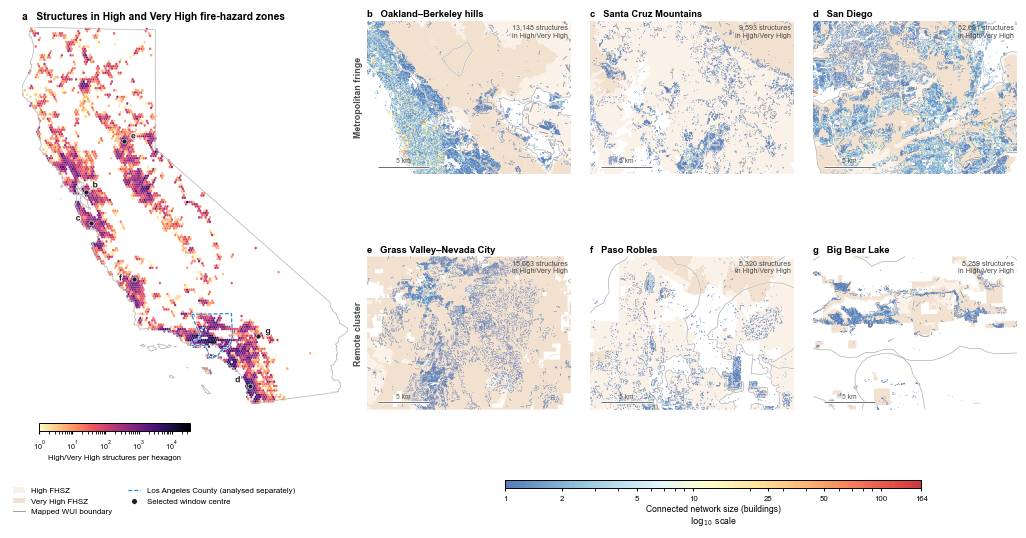

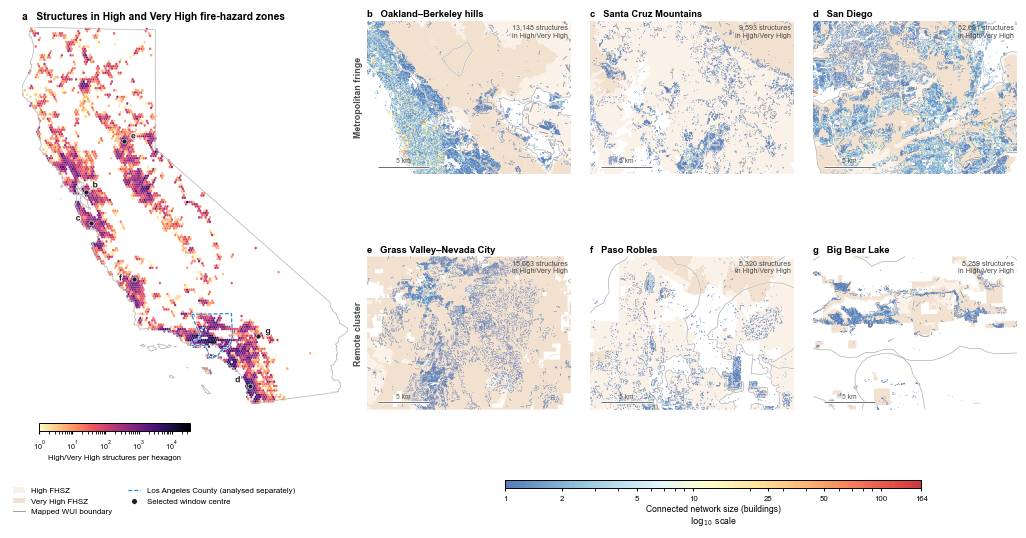

In [31]:
# Hazard-weighted community atlas: six windows selected by rule, not by hand.
# Every 20 x 15 km window on a 1.25 km search grid is scored by the structures
# it contains inside High or Very High FHSZ. Los Angeles County is excluded
# because it is analysed separately, and one window is kept for each
# (settlement context x macroregion) cell so the six panels stay spread across
# California and span major-metropolitan and remote clustered settlement.
from matplotlib import patheffects
from matplotlib.patches import Patch
from pyproj import Transformer
import shapely

HAZARD_CLASSES = ('High', 'Very High')
# Identical 20 x 15 km windows to the coastal-interior atlas keep the two
# figures directly comparable.
WINDOW_HALF_WIDTH_M, WINDOW_HALF_HEIGHT_M = 10_000, 7_500
SEARCH_CELL_M = 1_250
CONTEXT_HALF_SIDE_M = 30_000
METROPOLITAN_CONTEXT_MINIMUM = 250_000
REMOTE_CONTEXT_MAXIMUM = 60_000
MINIMUM_SEPARATION_M = 60_000
LA_EXCLUSION_BUFFER_M = 25_000
SETTING_ORDER = ['Metropolitan fringe', 'Remote cluster']
LA_COUNTY_BOUNDARY = (
    SOURCE_PROJECT / 'data' / 'reference' / 'la_county_mainland_boundary.parquet'
)
# Anchors name each panel; a selection that drifts beyond the tolerance falls
# back to its coordinates rather than carrying a stale place name.
PLACE_ANCHORS = {
    ('Metropolitan fringe', 'Southern California'): ('San Diego', -117.160, 32.975),
    ('Metropolitan fringe', 'Central California'): ('Santa Cruz Mountains', -122.034, 37.104),
    ('Metropolitan fringe', 'Northern California'): ('Oakland–Berkeley hills', -122.213, 37.899),
    ('Remote cluster', 'Southern California'): ('Big Bear Lake', -116.871, 34.231),
    ('Remote cluster', 'Central California'): ('Paso Robles', -120.614, 35.702),
    ('Remote cluster', 'Northern California'): ('Grass Valley–Nevada City', -121.006, 39.186),
}
PLACE_ANCHOR_TOLERANCE_M = 8_000

hazard_frame = network_classified[[
    'building_id', 'component_id', 'component_size', 'severity',
]].merge(
    pd.read_parquet(STATE_CENTROIDS, columns=['building_id', 'x', 'y']),
    on='building_id', how='left', validate='one_to_one',
)
is_hazard = hazard_frame.severity.isin(HAZARD_CLASSES).to_numpy()

grid_x0 = np.floor(hazard_frame.x.min() / SEARCH_CELL_M) * SEARCH_CELL_M
grid_y0 = np.floor(hazard_frame.y.min() / SEARCH_CELL_M) * SEARCH_CELL_M
column_index = ((hazard_frame.x.to_numpy() - grid_x0) // SEARCH_CELL_M).astype(np.int64)
row_index = ((hazard_frame.y.to_numpy() - grid_y0) // SEARCH_CELL_M).astype(np.int64)
n_columns = int(column_index.max()) + 1
n_rows = int(row_index.max()) + 1
cell_index = row_index * n_columns + column_index


def _integral_counts(selector):
    """Summed-area table of structure counts on the search grid."""
    counts = np.bincount(
        cell_index[selector], minlength=n_rows * n_columns,
    ).reshape(n_rows, n_columns)
    padded = np.pad(counts.astype(np.int64), ((1, 0), (1, 0)))
    return np.cumsum(np.cumsum(padded, axis=0), axis=1)


def _box_totals(integral, row_centers, column_centers, half_rows, half_columns):
    """Structures inside boxes centred on the given grid intersections."""
    row_low = np.clip(row_centers - half_rows, 0, n_rows)
    row_high = np.clip(row_centers + half_rows, 0, n_rows)
    column_low = np.clip(column_centers - half_columns, 0, n_columns)
    column_high = np.clip(column_centers + half_columns, 0, n_columns)
    return (
        integral[row_high, column_high] - integral[row_low, column_high]
        - integral[row_high, column_low] + integral[row_low, column_low]
    )


half_columns_window = int(WINDOW_HALF_WIDTH_M / SEARCH_CELL_M)
half_rows_window = int(WINDOW_HALF_HEIGHT_M / SEARCH_CELL_M)
half_side_context = int(CONTEXT_HALF_SIDE_M / SEARCH_CELL_M)
center_rows, center_columns = np.meshgrid(
    np.arange(n_rows + 1), np.arange(n_columns + 1), indexing='ij',
)
all_integral = _integral_counts(np.ones(len(hazard_frame), bool))
hazard_integral = _integral_counts(is_hazard)
hazard_sen_integral = _integral_counts(
    is_hazard & hazard_frame.component_size.ge(10).to_numpy()
)
window_arguments = (center_rows, center_columns, half_rows_window, half_columns_window)
candidates = pd.DataFrame({
    'x': (grid_x0 + center_columns * SEARCH_CELL_M).ravel(),
    'y': (grid_y0 + center_rows * SEARCH_CELL_M).ravel(),
    'hazard_structures': _box_totals(hazard_integral, *window_arguments).ravel(),
    'structures': _box_totals(all_integral, *window_arguments).ravel(),
    'hazard_structures_in_sen_ge_10': _box_totals(
        hazard_sen_integral, *window_arguments,
    ).ravel(),
    'context_structures': _box_totals(
        all_integral, center_rows, center_columns,
        half_side_context, half_side_context,
    ).ravel(),
})
candidates = candidates.loc[candidates.hazard_structures.gt(0)].reset_index(drop=True)

to_wgs84_windows = Transformer.from_crs(3310, 4326, always_xy=True)
candidates['longitude'], candidates['latitude'] = to_wgs84_windows.transform(
    candidates.x.to_numpy(), candidates.y.to_numpy(),
)
candidates['major_region'] = pd.cut(
    candidates.latitude, bins=[-np.inf, 35.0, 37.5, np.inf],
    labels=REGION_ORDER, right=False, ordered=True,
)
la_county = gpd.read_parquet(LA_COUNTY_BOUNDARY).to_crs(3310)
la_excluded_geometry = la_county.geometry.union_all().buffer(LA_EXCLUSION_BUFFER_M)
shapely.prepare(la_excluded_geometry)
candidates['inside_los_angeles'] = shapely.intersects_xy(
    la_excluded_geometry, candidates.x.to_numpy(), candidates.y.to_numpy(),
)
candidates['setting'] = np.where(
    candidates.context_structures.ge(METROPOLITAN_CONTEXT_MINIMUM),
    SETTING_ORDER[0],
    np.where(
        candidates.context_structures.le(REMOTE_CONTEXT_MAXIMUM),
        SETTING_ORDER[1], 'Intermediate',
    ),
)

eligible = candidates.loc[~candidates.inside_los_angeles]
selected_rows = []
selected_centers = []
for setting in SETTING_ORDER:
    filled_regions = set()
    stratum = eligible.loc[eligible.setting.eq(setting)].sort_values(
        'hazard_structures', ascending=False,
    )
    for row in stratum.itertuples():
        if row.major_region in filled_regions:
            continue
        if any(
            np.hypot(row.x - center[0], row.y - center[1]) < MINIMUM_SEPARATION_M
            for center in selected_centers
        ):
            continue
        filled_regions.add(row.major_region)
        selected_centers.append((row.x, row.y))
        selected_rows.append(row)
        if len(filled_regions) == len(REGION_ORDER):
            break
    if len(filled_regions) != len(REGION_ORDER):
        raise RuntimeError(
            f'{setting} did not yield one window per macroregion; '
            'revisit the context thresholds.'
        )

hazard_atlas = pd.DataFrame([
    {
        'setting': row.setting, 'major_region': row.major_region,
        'x': row.x, 'y': row.y,
        'longitude': row.longitude, 'latitude': row.latitude,
        'hazard_structures': int(row.hazard_structures),
        'structures': int(row.structures),
        'hazard_structures_in_sen_ge_10': int(row.hazard_structures_in_sen_ge_10),
        'context_structures': int(row.context_structures),
    }
    for row in selected_rows
])
hazard_atlas['setting'] = pd.Categorical(
    hazard_atlas.setting, SETTING_ORDER, ordered=True,
)
hazard_atlas = hazard_atlas.sort_values(
    ['setting', 'latitude'], ascending=[True, False],
).reset_index(drop=True)
hazard_atlas['panel'] = list('bcdefg')

place_names = []
for row in hazard_atlas.itertuples():
    name, anchor_longitude, anchor_latitude = PLACE_ANCHORS[
        (row.setting, row.major_region)
    ]
    anchor_x, anchor_y = Transformer.from_crs(4326, 3310, always_xy=True).transform(
        anchor_longitude, anchor_latitude,
    )
    drift_m = float(np.hypot(row.x - anchor_x, row.y - anchor_y))
    if drift_m > PLACE_ANCHOR_TOLERANCE_M:
        print(
            f'panel {row.panel}: selection moved {drift_m / 1000:.1f} km from '
            f'the "{name}" anchor; labelling by coordinates instead.'
        )
        name = f'{abs(row.latitude):.2f}°N {abs(row.longitude):.2f}°W'
    place_names.append(name)
hazard_atlas['place'] = place_names

# Runner-up windows keep the rule auditable: the Sierra foothill candidates in
# particular are close together in score, so the alternatives are written out.
audit_rows = []
for setting in SETTING_ORDER:
    stratum = eligible.loc[eligible.setting.eq(setting)].sort_values(
        'hazard_structures', ascending=False,
    )
    kept_centers = []
    for row in stratum.itertuples():
        if any(
            np.hypot(row.x - center[0], row.y - center[1]) < MINIMUM_SEPARATION_M
            for center in kept_centers
        ):
            continue
        kept_centers.append((row.x, row.y))
        audit_rows.append({
            'setting': setting, 'rank': len(kept_centers),
            'major_region': row.major_region,
            'longitude': row.longitude, 'latitude': row.latitude,
            'hazard_structures': int(row.hazard_structures),
            'structures': int(row.structures),
            'context_structures': int(row.context_structures),
            'selected': (row.x, row.y) in set(selected_centers),
        })
        if len(kept_centers) == 8:
            break
hazard_candidate_audit = pd.DataFrame(audit_rows)
hazard_candidate_audit.to_csv(
    RESULTS / 'california_ctop2_alpha075_high_hazard_atlas_candidates_p50.csv',
    index=False,
)
hazard_atlas['view_xmin'] = hazard_atlas.x - WINDOW_HALF_WIDTH_M
hazard_atlas['view_xmax'] = hazard_atlas.x + WINDOW_HALF_WIDTH_M
hazard_atlas['view_ymin'] = hazard_atlas.y - WINDOW_HALF_HEIGHT_M
hazard_atlas['view_ymax'] = hazard_atlas.y + WINDOW_HALF_HEIGHT_M

with duckdb.connect() as con:
    con.register('hazard_bounds', hazard_atlas[[
        'panel', 'place', 'view_xmin', 'view_xmax', 'view_ymin', 'view_ymax',
    ]])
    hazard_window_buildings = con.execute(
        '''
        SELECT r.panel, r.place, c.building_id, c.x, c.y,
               a.component_id, a.component_size
        FROM hazard_bounds r
        JOIN read_parquet(?) c
          ON c.x BETWEEN r.view_xmin AND r.view_xmax
         AND c.y BETWEEN r.view_ymin AND r.view_ymax
        JOIN read_parquet(?) a USING (building_id)
        ''',
        [str(STATE_CENTROIDS), str(top2_paths['assignments'])],
    ).fetchdf()

# ---------------------------------------------------------------- figure ----
if 'mapped_wui_geometry' not in globals():
    mapped_wui_geometry = pd.concat(
        [frame.geometry for frame in wui_classes.values()], ignore_index=True,
    ).union_all()
hazard_polygons = fhsz.loc[fhsz.FHSZ_Description.isin(HAZARD_CLASSES)]
HAZARD_FILL = {'High': '#FAF2E8', 'Very High': '#F3E1D0'}
largest_state_component = int(statewide_summary.largest_component.iloc[0])
hazard_norm = LogNorm(vmin=1, vmax=largest_state_component)
hazard_palette = mpl.colormaps['RdYlBu_r'](np.linspace(.08, .94, 256))
hazard_palette[:, :3] = .88 * hazard_palette[:, :3] + .12
hazard_cmap = LinearSegmentedColormap.from_list('RdYlBu_r_pale', hazard_palette)

fig_hazard = plt.figure(figsize=(10.4, 5.6))
hazard_grid = fig_hazard.add_gridspec(
    2, 4, width_ratios=(1.60, 1, 1, 1), hspace=.14, wspace=.08,
)
hazard_state_ax = fig_hazard.add_subplot(hazard_grid[:, 0])
hazard_axes = [
    fig_hazard.add_subplot(hazard_grid[row, column])
    for row in range(2) for column in (1, 2, 3)
]

state_bounds = boundary.total_bounds
hazard_points = hazard_frame.loc[is_hazard]
state_hazard_hex = hazard_state_ax.hexbin(
    hazard_points.x, hazard_points.y, gridsize=150, mincnt=1,
    extent=(state_bounds[0], state_bounds[2], state_bounds[1], state_bounds[3]),
    cmap='magma_r', bins='log', linewidths=0, rasterized=True, zorder=1,
)
boundary.boundary.plot(ax=hazard_state_ax, color='#B8B8B8', linewidth=.55, zorder=4)
la_outline = la_county.boundary.plot(
    ax=hazard_state_ax, color='#2E86C1', linewidth=.9, linestyle=(0, (3, 1.6)),
    zorder=5,
)
for artist in la_outline.collections[-1:]:
    artist.set_path_effects([
        patheffects.withStroke(linewidth=1.9, foreground='white'),
    ])
hazard_state_ax.scatter(
    hazard_atlas.x, hazard_atlas.y, s=13, facecolor='#202020',
    edgecolor='white', linewidth=.4, zorder=6,
)
hazard_label_offsets = {
    'b': (5, 3), 'c': (-11, 2), 'd': (-11, 3),
    'e': (5, 2), 'f': (-11, -1), 'g': (5, 2),
}
for row in hazard_atlas.itertuples():
    hazard_state_ax.annotate(
        row.panel, (row.x, row.y), xytext=hazard_label_offsets[row.panel],
        textcoords='offset points', fontsize=6.2, fontweight='bold',
        color='#202020', zorder=7,
        path_effects=[patheffects.withStroke(linewidth=1.6, foreground='white')],
    )
hazard_state_ax.set(
    xlim=(state_bounds[0], state_bounds[2]),
    ylim=(state_bounds[1], state_bounds[3]), aspect='equal',
)
hazard_state_ax.axis('off')
hazard_state_ax.set_title(
    'a   Structures in High and Very High fire-hazard zones', loc='left',
    fontsize=7.4, fontweight='bold', pad=5,
)

for ax, region in zip(hazard_axes, hazard_atlas.itertuples()):
    view_box = box(
        region.view_xmin, region.view_ymin, region.view_xmax, region.view_ymax,
    )
    for severity in HAZARD_CLASSES:
        local_hazard = hazard_polygons.loc[
            hazard_polygons.FHSZ_Description.eq(severity)
        ].cx[
            region.view_xmin:region.view_xmax,
            region.view_ymin:region.view_ymax,
        ]
        if local_hazard.empty:
            continue
        local_hazard.clip(view_box).plot(
            ax=ax, facecolor=HAZARD_FILL[severity], edgecolor='none', zorder=1,
        )
    window_points = hazard_window_buildings.loc[
        hazard_window_buildings.panel.eq(region.panel)
    ]
    marker_sizes = .28 + .24 * (
        np.log10(window_points.component_size) / np.log10(largest_state_component)
    )
    ax.scatter(
        window_points.x, window_points.y, c=window_points.component_size,
        cmap=hazard_cmap, norm=hazard_norm, s=marker_sizes, linewidths=0,
        alpha=.92, rasterized=True, zorder=3,
    )
    local_wui_boundary = mapped_wui_geometry.boundary.intersection(view_box)
    if not local_wui_boundary.is_empty:
        gpd.GeoSeries([local_wui_boundary], crs=3310).plot(
            ax=ax, color='white', linewidth=.85, zorder=4,
        )
        gpd.GeoSeries([local_wui_boundary], crs=3310).plot(
            ax=ax, color='#9E9E9E', linewidth=.50, alpha=.82, zorder=5,
        )
    ax.set(
        xlim=(region.view_xmin, region.view_xmax),
        ylim=(region.view_ymin, region.view_ymax), aspect='equal',
    )
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(
        f'{region.panel}   {region.place}', loc='left',
        fontsize=6.8, fontweight='bold', pad=3,
    )
    ax.text(
        .985, .975, f'{region.hazard_structures:,} structures\nin High/Very High',
        transform=ax.transAxes, ha='right', va='top', fontsize=5.2,
        color='#4A4A4A', linespacing=1.25, zorder=8,
    )
    scale_x = region.view_xmin + 1_050
    scale_y = region.view_ymin + 700
    ax.plot([scale_x, scale_x + 5_000], [scale_y, scale_y],
            color='white', lw=1.8, solid_capstyle='butt', zorder=8)
    ax.plot([scale_x, scale_x + 5_000], [scale_y, scale_y],
            color='#555555', lw=.60, solid_capstyle='butt', zorder=9)
    ax.text(scale_x + 2_500, scale_y + 280, '5 km', ha='center', va='bottom',
            fontsize=4.8, color='#555555', zorder=9)

row_label_positions = {
    SETTING_ORDER[0]: hazard_axes[0], SETTING_ORDER[1]: hazard_axes[3],
}
for setting, ax in row_label_positions.items():
    ax.text(
        -.02, .5, setting, transform=ax.transAxes, rotation=90,
        ha='right', va='center', fontsize=6.4, fontweight='bold',
        color='#4A4A4A',
    )

fig_hazard.legend(handles=[
    Patch(facecolor=HAZARD_FILL['High'], edgecolor='none', label='High FHSZ'),
    Patch(facecolor=HAZARD_FILL['Very High'], edgecolor='none', label='Very High FHSZ'),
    Line2D([], [], color='#9E9E9E', lw=.7, label='Mapped WUI boundary'),
    Line2D([], [], color='#2E86C1', lw=.9, ls=(0, (3, 1.6)),
           label='Los Angeles County (analysed separately)'),
    Line2D([], [], marker='o', ls='', markerfacecolor='#202020',
           markeredgecolor='white', markeredgewidth=.35, markersize=4.0,
           label='Selected window centre'),
], loc='lower left', bbox_to_anchor=(.020, .012), ncol=2, frameon=False,
   fontsize=5.7, handlelength=1.5)

hazard_state_cbar_ax = fig_hazard.add_axes([.052, .175, .145, .014])
hazard_state_cbar = fig_hazard.colorbar(
    state_hazard_hex, cax=hazard_state_cbar_ax, orientation='horizontal',
)
hazard_state_cbar.set_label(
    'High/Very High structures per hexagon', fontsize=5.6, labelpad=1.5,
)
hazard_state_cbar.ax.tick_params(labelsize=5.2, length=2)

hazard_cbar_ax = fig_hazard.add_axes([.50, .072, .40, .015])
hazard_cbar = fig_hazard.colorbar(
    mpl.cm.ScalarMappable(norm=hazard_norm, cmap=hazard_cmap),
    cax=hazard_cbar_ax, orientation='horizontal',
)
hazard_ticks = np.unique(
    np.array([1, 2, 5, 10, 25, 50, 100, largest_state_component])
)
hazard_cbar.set_ticks(hazard_ticks)
hazard_cbar.set_ticklabels([f'{value:,}' for value in hazard_ticks])
hazard_cbar.set_label(
    'Connected network size (buildings)\n$\\log_{10}$ scale',
    fontsize=6.2, labelpad=1.5,
)
hazard_cbar.ax.tick_params(labelsize=5.6, length=2)
fig_hazard.subplots_adjust(left=.035, right=.992, top=.955, bottom=.165)

hazard_atlas_summary = hazard_atlas.merge(
    hazard_window_buildings.groupby('panel', as_index=False).agg(
        displayed_buildings=('building_id', 'nunique'),
        displayed_components=('component_id', 'nunique'),
        largest_displayed_component=('component_size', 'max'),
    ),
    on='panel', validate='one_to_one',
)
hazard_atlas_summary.to_csv(
    RESULTS / 'california_ctop2_alpha075_high_hazard_atlas_p50.csv', index=False,
)
hazard_stem = (
    FIGURES / 'carsen_california_ctop2_alpha075_high_hazard_atlas_p50'
)
fig_hazard.savefig(
    hazard_stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white',
)
fig_hazard.savefig(
    hazard_stem.with_suffix('.png'), dpi=600, bbox_inches='tight', facecolor='white',
)
display(hazard_atlas_summary[[
    'panel', 'place', 'setting', 'major_region', 'hazard_structures',
    'structures', 'hazard_structures_in_sen_ge_10', 'context_structures',
    'largest_displayed_component',
]])
print('saved', hazard_stem.with_suffix('.png'))
fig_hazard